# KDD sobre dataset de alquileres

In [229]:
#Imports

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Análisis exploratorio de los datos (EDA)

## Análisis general

In [ ]:
# Carga del dataset inicial
ruta_ventas = "Datos/alquiler.csv"

df = pd.read_csv(ruta_ventas)

# Filtrar viviendas de Madrid ciudad
df_madrid = df[
    df["location"].str.contains("Madrid city", case=False, na=False)
].copy()

print("Registros originales:", len(df))
print("Registros Madrid ciudad:", len(df_madrid))
print("Registros eliminados:", len(df) - len(df_madrid))

df=df_madrid

print("Número de observaciones:", df.shape[0])
print("Número de variables:", df.shape[1])

display(df.head())

Registros originales: 9229
Registros Madrid ciudad: 8176
Registros eliminados: 1053
Número de observaciones: 8176
Número de variables: 24


,title,type,price,private_owner,professional_name,floor_built,floor_area,floor,year_built,orientation,bedrooms,bathrooms,second_hand,lift,garage_included,furnished,terrace,balcony,storeroom,swimming_pool,garden_area,location,district,postalcode
0,"Flat / apartment for rent in pablo luna, 4",Flat,1400,False,Silcasas Ochocientas,60,NaN,3rd,"1.954,00",NaN,2,1,True,True,False,True,True,False,False,False,False,"pablo luna, 4, Subdistrict Castilla, District ...",Chamartín,"28.046,00"
1,Penthouse for rent in calle de Bolivia,Penthouse,1300,False,Cruzity,77,NaN,6th,"1.961,00",NaN,2,2,True,True,False,True,False,False,False,False,False,"Calle de Bolivia, Subdistrict Bernabéu-Hispano...",Chamartín,"28.016,00"
2,Duplex for rent in calle de la constancia,Duplex,950,False,Mm Home,72,"68,00",3rd,"1.999,00",east,1,1,True,True,False,True,True,False,False,False,False,"Calle de la constancia, Urb. no, Subdistrict P...",Chamartín,"28.002,00"
3,"Flat / apartment for rent in Urb. el viso, El ...",Flat,2975,False,B&H Partners,160,NaN,3rd,NaN,west,4,3,True,True,True,True,True,False,False,True,False,"Urb. el viso, Subdistrict El Viso, District Ch...",Chamartín,NaN
4,Studio flat for rent in luis cabrera,Studio,650,False,Madrid en Propiedad,30,NaN,4th,NaN,NaN,0,1,True,True,False,True,False,True,False,False,False,"luis cabrera, Subdistrict Prosperidad, Distric...",Chamartín,"28.002,00"


In [231]:
# Información general de columnas

tabla_info = pd.DataFrame({
    "Variable": df.columns,
    "Tipo de dato": df.dtypes.astype(str).values,
    "Valores no nulos": df.notna().sum().values,
    "Valores nulos": df.isna().sum().values,
    "% nulos": (df.isna().mean().values * 100).round(2),
    "Valores únicos": df.nunique().values
})

tabla_info

,Variable,Tipo de dato,Valores no nulos,Valores nulos,% nulos,Valores únicos
0,title,str,8176,0,"0,00",4970
1,type,str,8176,0,"0,00",8
2,price,int64,8176,0,"0,00",627
3,private_owner,bool,8176,0,"0,00",2
4,professional_name,str,6812,1364,"16,68",1341
5,floor_built,int64,8176,0,"0,00",353
6,floor_area,float64,3476,4700,"57,49",254
7,floor,str,7927,249,"3,05",152
8,year_built,float64,2488,5688,"69,57",129
9,orientation,str,3858,4318,"52,81",4


Análisis de la variable objetivo

In [232]:
variable_objetivo = "price"

df[variable_objetivo].describe().apply(lambda x: f"{x:,.0f} €")

count     8,176 €
mean      1,966 €
std       1,552 €
min         450 €
25%       1,050 €
50%       1,450 €
75%       2,400 €
max      25,000 €
Name: price, dtype: str

N° de registros duplicados

In [233]:
duplicados = df.duplicated().sum()

print("Número de registros duplicados:", duplicados)

Número de registros duplicados: 61


## Análisis univariante

In [234]:
# Definición de los tipos de variables

variables_numericas = [
    "price",
    "floor_built",
    "floor_area",
    "year_built",
    "bedrooms",
    "bathrooms"
]

variables_categoricas = [
    "type",
    "private_owner",
    "professional_name",
    "floor",
    "orientation",
    "second_hand",
    "lift",
    "garage_included",
    "furnished",
    "terrace",
    "balcony",
    "storeroom",
    "swimming_pool",
    "garden_area",
    "district",
    "postalcode"
]

variables_textuales = [
    "title",
    "location"
]

### Distribución de las variables numéricas

In [235]:
pd.set_option(
    "display.float_format",
    lambda x: f"{x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
)

df.describe()

,price,floor_built,floor_area,year_built,bedrooms,bathrooms,postalcode
count,"8.176,00","8.176,00","3.476,00","2.488,00","8.176,00","8.176,00","5.958,00"
mean,"1.966,48","104,60","90,30","1.971,83","2,18","1,74","28.022,10"
std,"1.552,34","77,33","65,21","35,85","1,29","1,02","15,86"
min,"450,00","0,00","0,00","1.800,00","0,00","1,00","28.001,00"
25%,"1.050,00","60,00","51,00","1.956,00","1,00","1,00","28.008,00"
50%,"1.450,00","82,00","73,00","1.973,00","2,00","1,00","28.020,00"
75%,"2.400,00","123,00","105,00","2.001,00","3,00","2,00","28.036,00"
max,"25.000,00","990,00","995,00","2.022,00","25,00","20,00","28.071,00"


### Histogramas

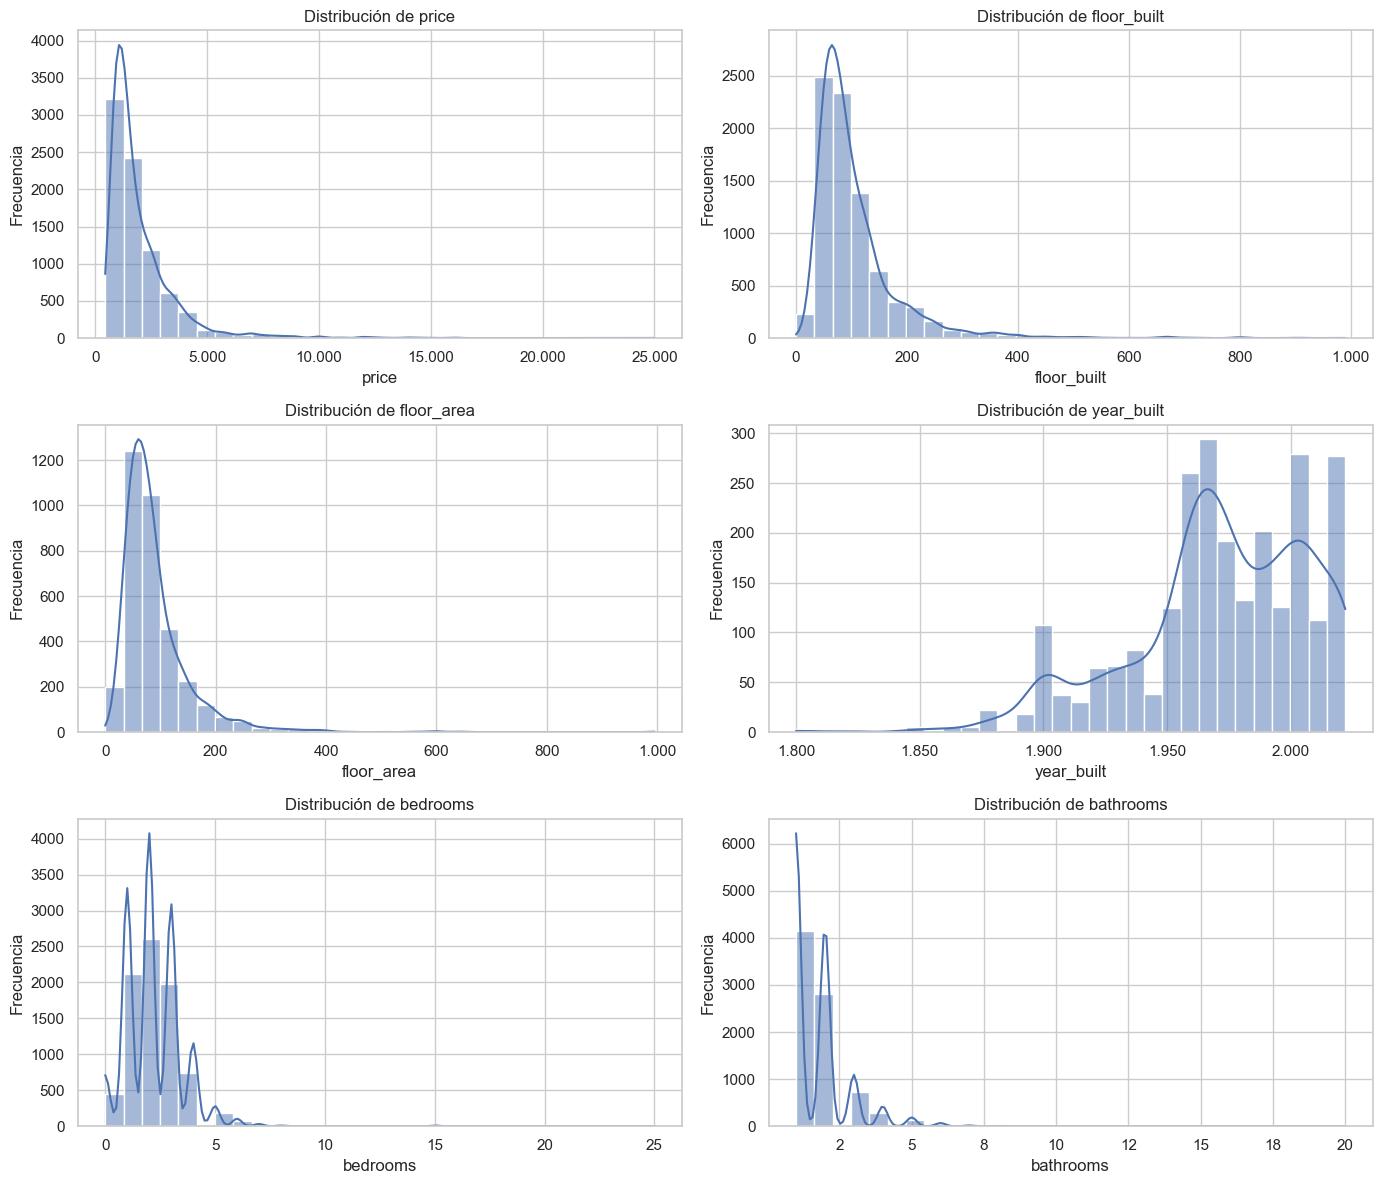

In [236]:
import math
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

def formato_miles(x, pos):
    return f"{x:,.0f}".replace(",", ".")

n_vars = len(variables_numericas)
n_cols = 2
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(variables_numericas):
    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(f"Distribución de {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")
    axes[i].xaxis.set_major_formatter(FuncFormatter(formato_miles))

# Eliminar ejes vacíos si sobran
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

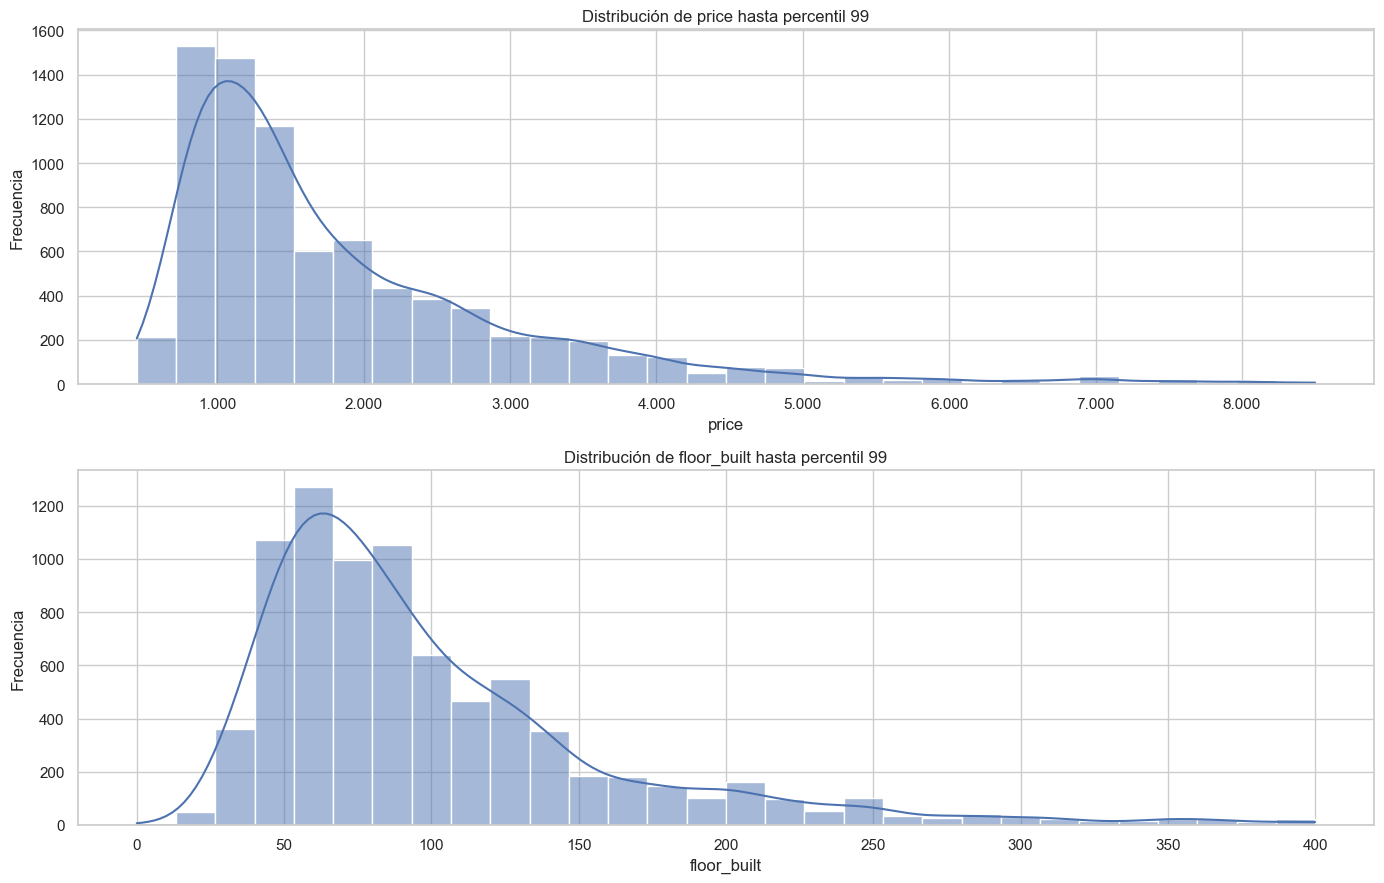

In [237]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

def formato_miles(x, pos):
    return f"{x:,.0f}".replace(",", ".")

fig, axes = plt.subplots(2, figsize=(14, 9))
axes = axes.flatten()

variables = ["price","floor_built"]

for i, col in enumerate(variables):
    
    if col in ["price", "floor_built"]:
        limite = df[col].quantile(0.99)
        datos_plot = df[df[col] <= limite]
        titulo = f"Distribución de {col} hasta percentil 99"
    else:
        datos_plot = df
        titulo = f"Distribución de {col}"
    
    sns.histplot(
        data=datos_plot,
        x=col,
        bins=30,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(titulo)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")

    axes[i].xaxis.set_major_formatter(FuncFormatter(formato_miles))

plt.tight_layout()
plt.show()

### Diagramas de caja

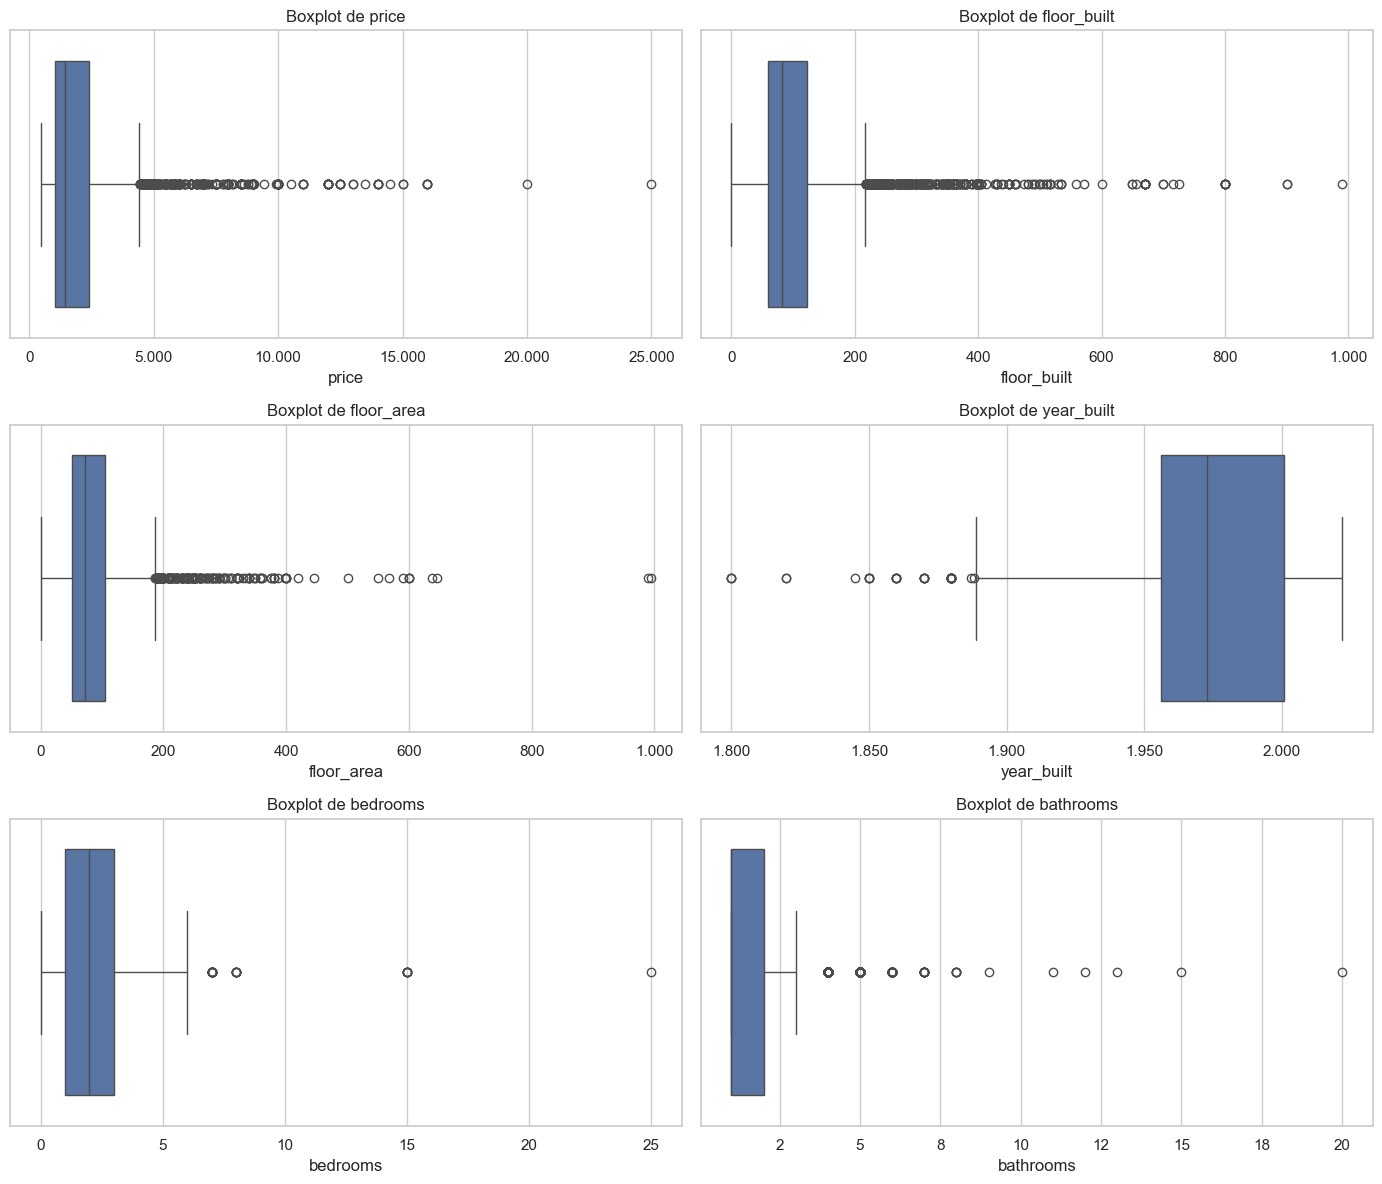

In [238]:
import math
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

def formato_miles(x, pos):
    return f"{x:,.0f}".replace(",", ".")

n_vars = len(variables_numericas)
n_cols = 2
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(variables_numericas):
    sns.boxplot(
        data=df,
        x=col,
        ax=axes[i]
    )
    
    axes[i].set_title(f"Boxplot de {col}")
    axes[i].set_xlabel(col)
    axes[i].xaxis.set_major_formatter(FuncFormatter(formato_miles))

# Eliminar ejes vacíos si sobran
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Diagramas de barras de variables categóricas

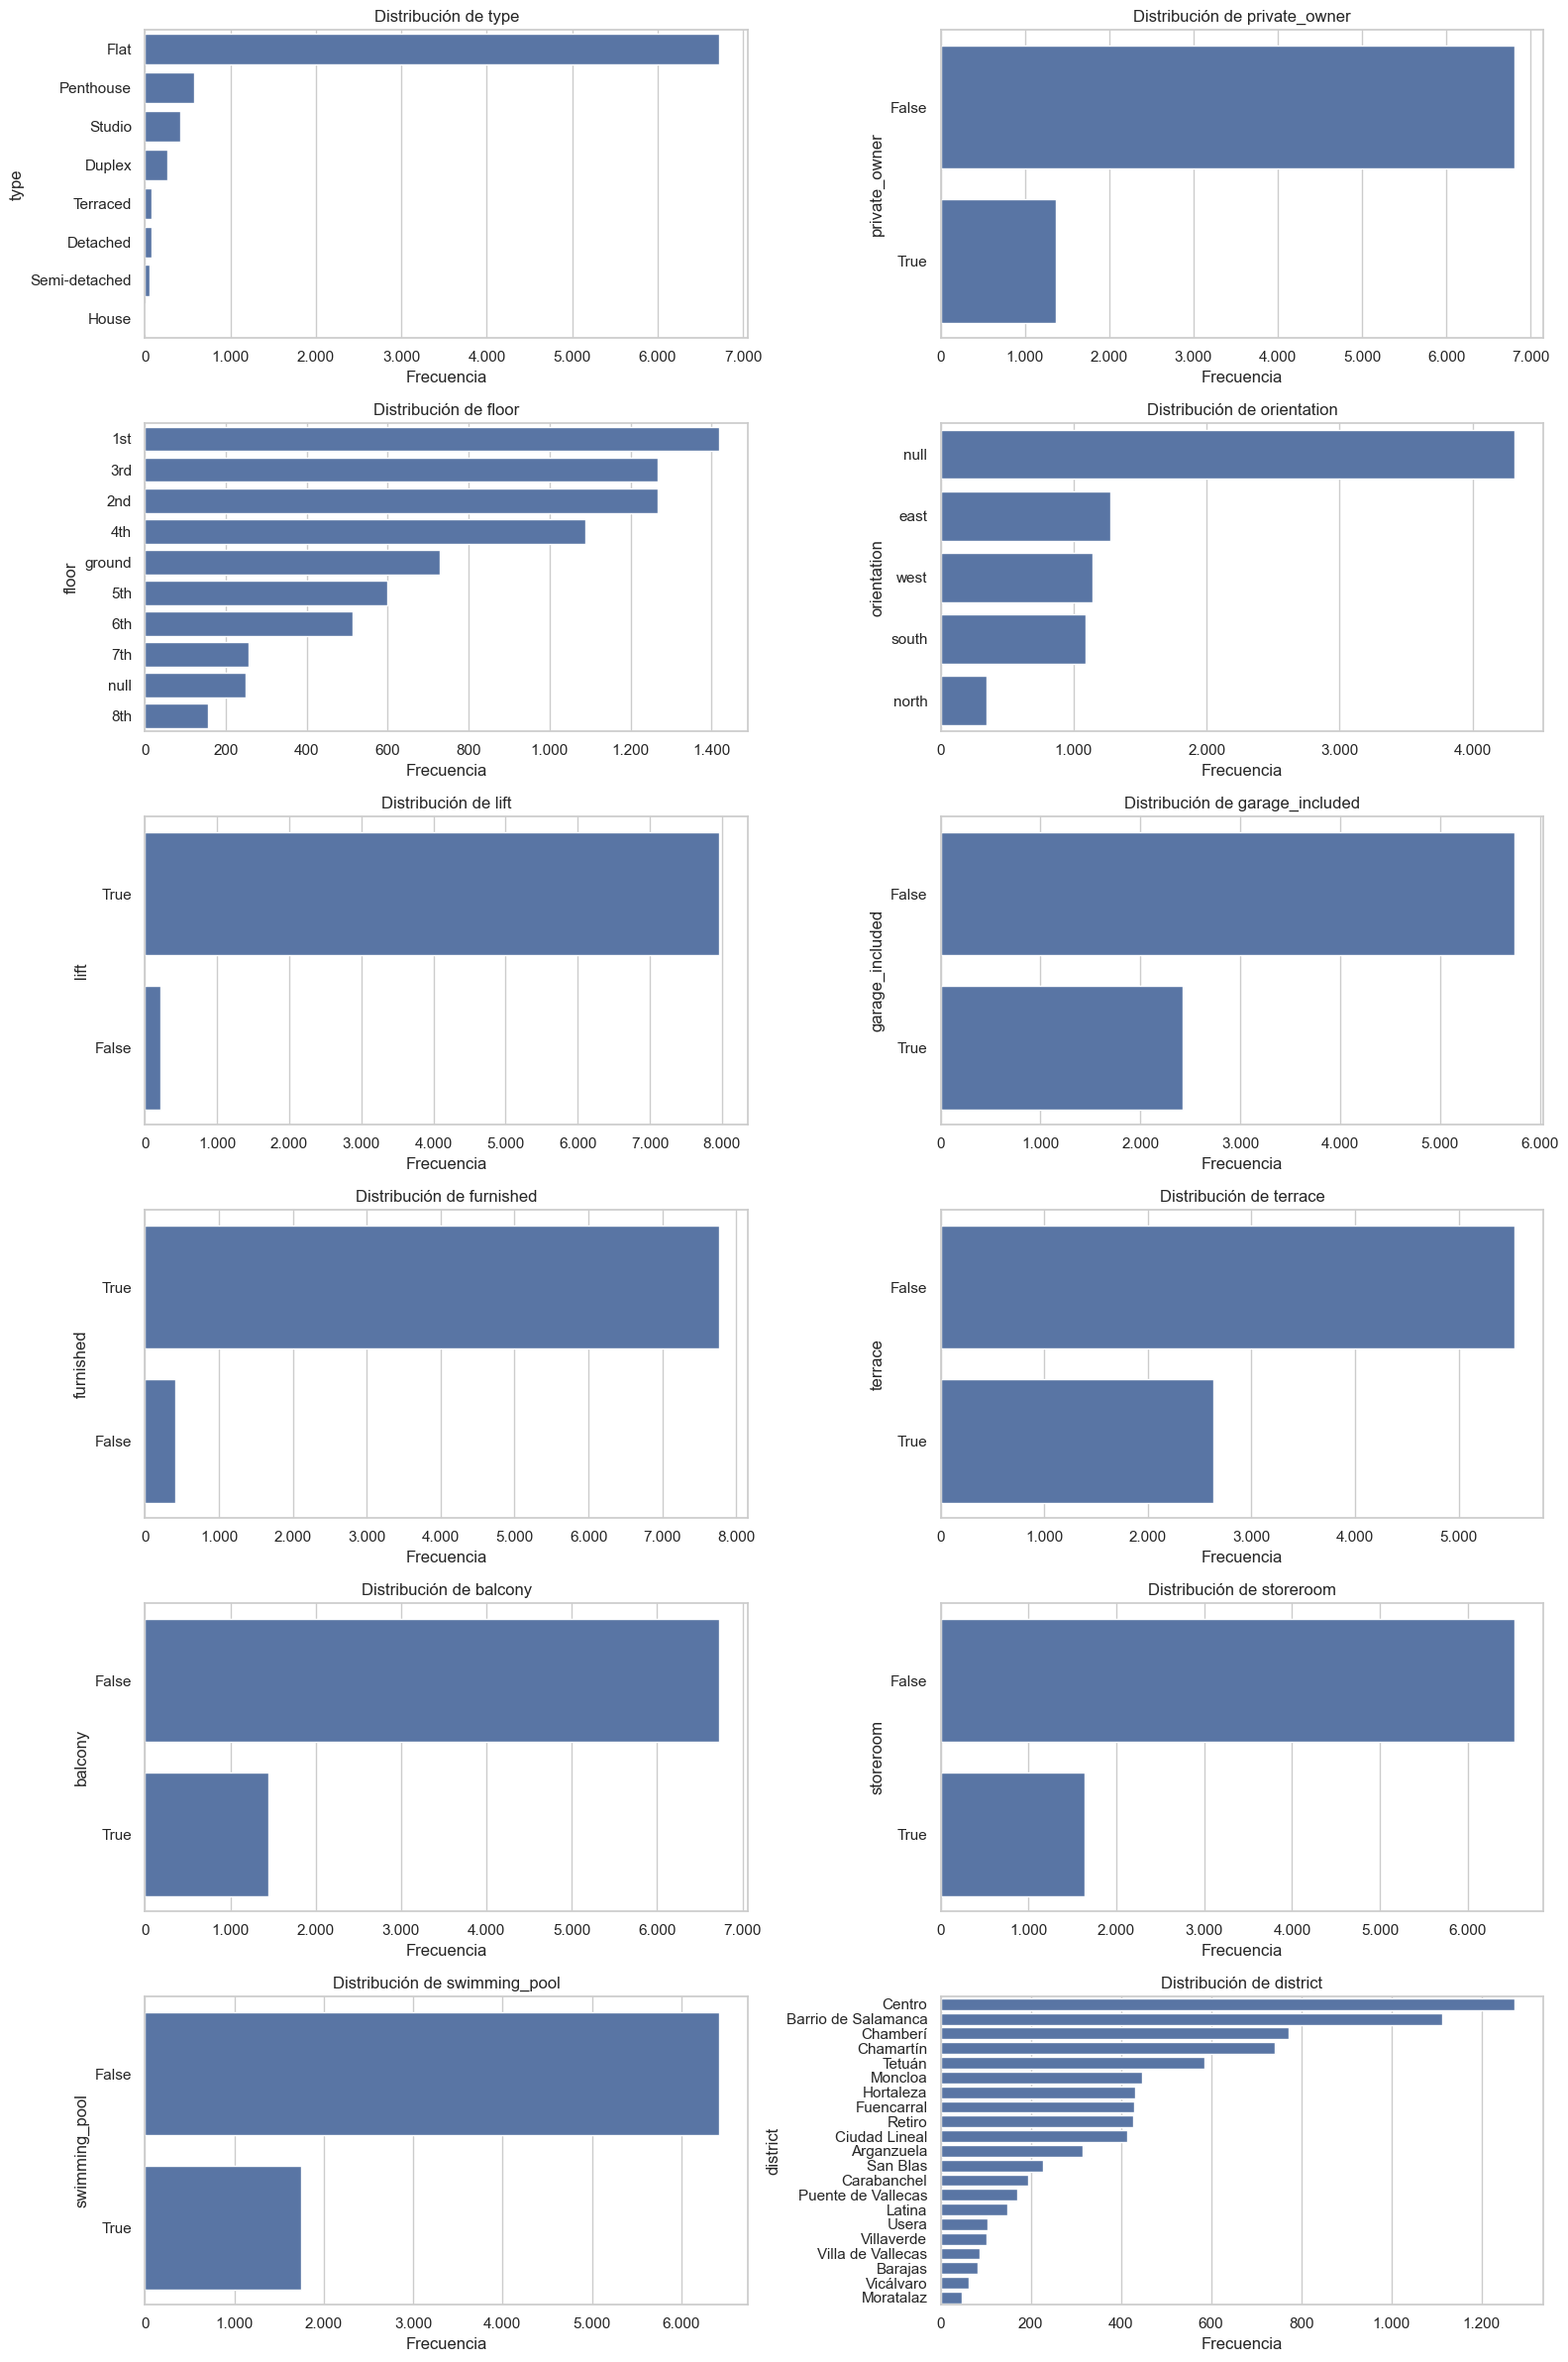

In [239]:
import math
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

def formato_miles(x, pos):
    return f"{x:,.0f}".replace(",", ".")

# Variables categóricas que NO se quieren representar
variables_excluir = [
    "postalcode",
    "garden_area",
    "second_hand",
    "professional_name"
]

# Variables categóricas finales para el gráfico
variables_categoricas_plot = [
    col for col in variables_categoricas 
    if col not in variables_excluir
]

n_vars = len(variables_categoricas_plot)
n_cols = 2
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(variables_categoricas_plot):

    datos_plot = df.copy()
    datos_plot[col] = datos_plot[col].fillna("null").astype(str)

    if col == "district":
        orden = datos_plot[col].value_counts().index
    else:
        orden = datos_plot[col].value_counts().head(10).index

    sns.countplot(
        data=datos_plot[datos_plot[col].isin(orden)],
        y=col,
        order=orden,
        ax=axes[i]
    )

    axes[i].set_title(f"Distribución de {col}")
    axes[i].set_xlabel("Frecuencia")
    axes[i].set_ylabel(col)
    axes[i].xaxis.set_major_formatter(FuncFormatter(formato_miles))

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

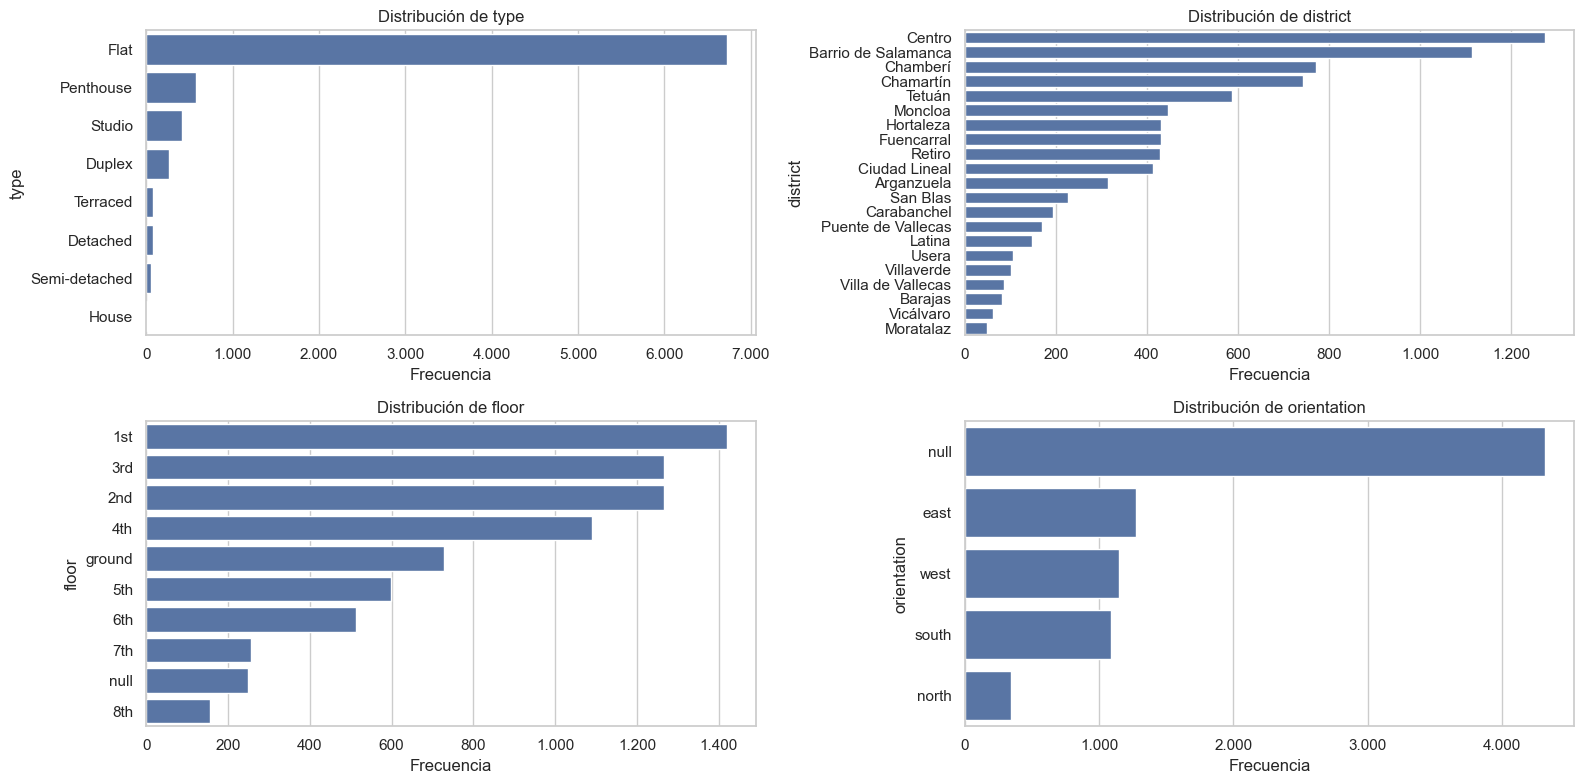

In [240]:
import math
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

def formato_miles(x, pos):
    return f"{x:,.0f}".replace(",", ".")

# Variables categóricas no binarias que sí queremos representar
variables_categoricas_no_binarias = [
    "type",
    "district",
    "floor",
    "orientation"
]

# Nos quedamos solo con las que existan realmente en el dataframe
variables_categoricas_no_binarias = [
    col for col in variables_categoricas_no_binarias
    if col in df.columns
]

n_vars = len(variables_categoricas_no_binarias)
n_cols = 2
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(variables_categoricas_no_binarias):
    
    datos_plot = df.copy()
    datos_plot[col] = datos_plot[col].fillna("null").astype(str)
    
    # Para district mostramos todos los distritos
    # Para el resto, solo las 10 categorías más frecuentes
    if col == "district":
        orden = datos_plot[col].value_counts().index
    else:
        orden = datos_plot[col].value_counts().head(10).index
    
    sns.countplot(
        data=datos_plot[datos_plot[col].isin(orden)],
        y=col,
        order=orden,
        ax=axes[i]
    )
    
    axes[i].set_title(f"Distribución de {col}")
    axes[i].set_xlabel("Frecuencia")
    axes[i].set_ylabel(col)
    axes[i].xaxis.set_major_formatter(FuncFormatter(formato_miles))

# Eliminar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

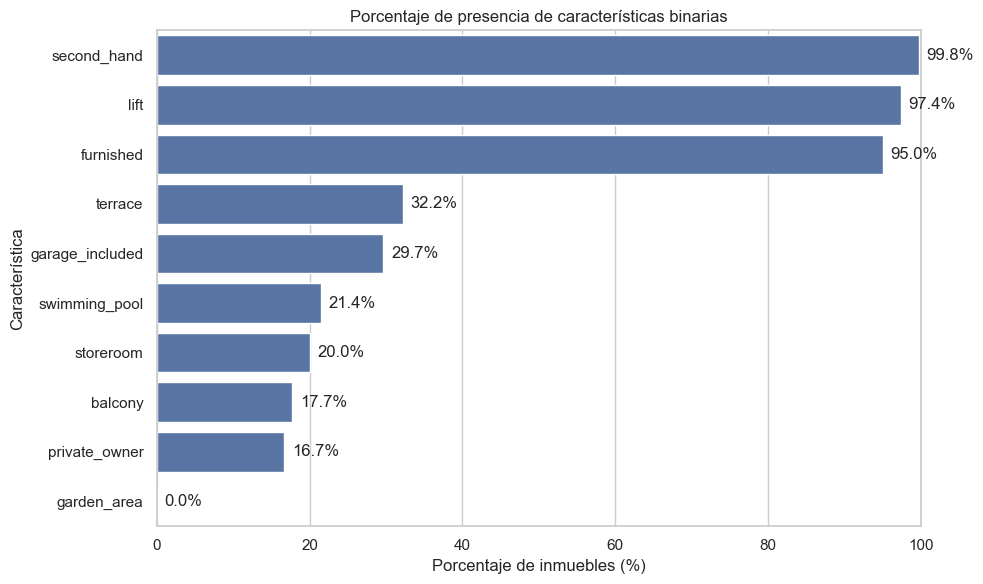

,Variable,Porcentaje_presencia
1,second_hand,"99,77"
2,lift,"97,37"
4,furnished,"95,02"
5,terrace,"32,22"
3,garage_included,"29,66"
8,swimming_pool,"21,43"
7,storeroom,"20,05"
6,balcony,"17,71"
0,private_owner,"16,68"
9,garden_area,"0,00"


In [241]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

variables_binarias = [
    "private_owner",
    "second_hand",
    "lift",
    "garage_included",
    "furnished",
    "terrace",
    "balcony",
    "storeroom",
    "swimming_pool",
    "garden_area"
]

variables_binarias = [
    col for col in variables_binarias
    if col in df.columns
]

resumen_binarias = []

for col in variables_binarias:
    porcentaje_true = df[col].mean() * 100
    
    resumen_binarias.append({
        "Variable": col,
        "Porcentaje_presencia": porcentaje_true
    })

resumen_binarias_df = pd.DataFrame(resumen_binarias)

resumen_binarias_df = resumen_binarias_df.sort_values(
    "Porcentaje_presencia",
    ascending=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=resumen_binarias_df,
    x="Porcentaje_presencia",
    y="Variable"
)

plt.title("Porcentaje de presencia de características binarias")
plt.xlabel("Porcentaje de inmuebles (%)")
plt.ylabel("Característica")
plt.xlim(0, 100)

for i, valor in enumerate(resumen_binarias_df["Porcentaje_presencia"]):
    plt.text(
        valor + 1,
        i,
        f"{valor:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

display(resumen_binarias_df.round(2))

In [242]:
tabla_planta = (
    df["floor"]
    .value_counts(dropna=False)
    .reset_index()
)

tabla_planta.columns = ["floor", "Frecuencia"]

tabla_planta["Porcentaje"] = (
    tabla_planta["Frecuencia"] / len(df) * 100
).round(2)

tabla_planta

,floor,Frecuencia,Porcentaje
0,1st,1419,"17,36"
1,3rd,1267,"15,50"
2,2nd,1266,"15,48"
3,4th,1089,"13,32"
4,ground,728,"8,90"
...,...,...,...
148,103,1,"0,01"
149,107,1,"0,01"
150,49,1,"0,01"
151,190,1,"0,01"


## Análisis bivariante

### Variables numéricas frente a variable objetivo (precio)

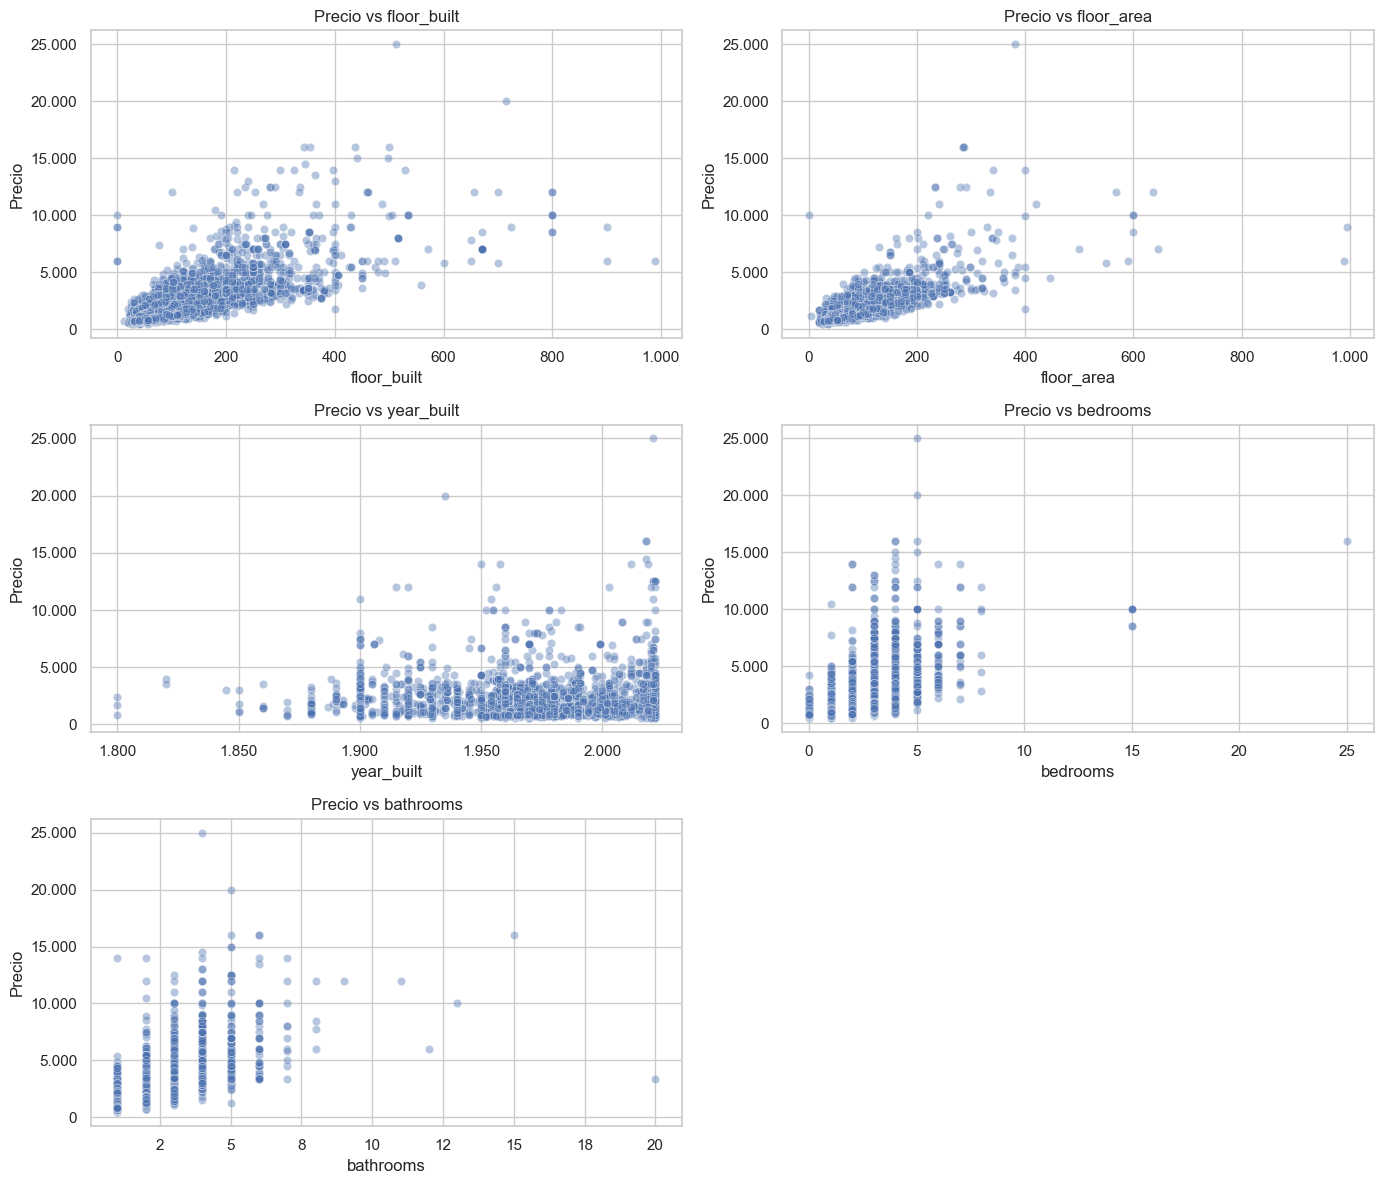

In [243]:
import math
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

variables_explicativas_numericas = [
    col for col in variables_numericas if col != "price"
]

n_vars = len(variables_explicativas_numericas)
n_cols = 2
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(variables_explicativas_numericas):
    
    sns.scatterplot(
        data=df,
        x=col,
        y="price",
        alpha=0.4,
        ax=axes[i]
    )
    
    axes[i].set_title(f"Precio vs {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Precio")

    axes[i].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", "."))
    )

    axes[i].xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", "."))
    )

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

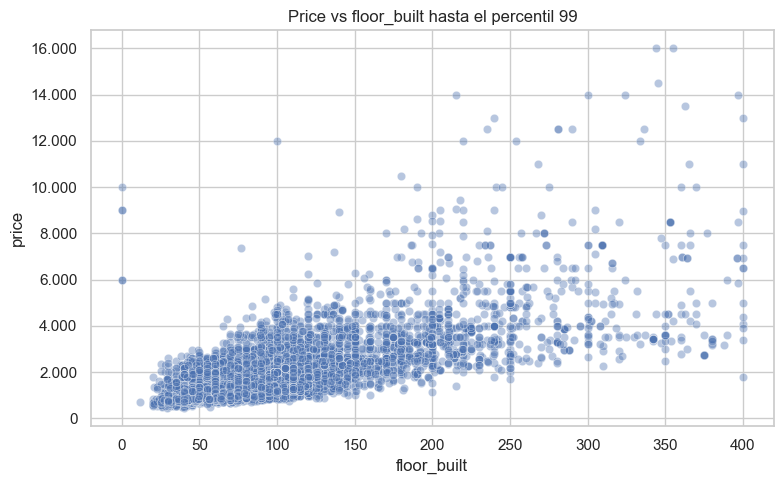

In [244]:
import matplotlib.ticker as mticker

limite_metros = df["floor_built"].quantile(0.99)

df_plot = df[df["floor_built"] <= limite_metros]

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_plot,
    x="floor_built",
    y="price",
    alpha=0.4
)

plt.title("Price vs floor_built hasta el percentil 99")
plt.xlabel("floor_built")
plt.ylabel("price")

plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", "."))
)

plt.tight_layout()
plt.show()

### Análisis del n° de baños respecto al precio

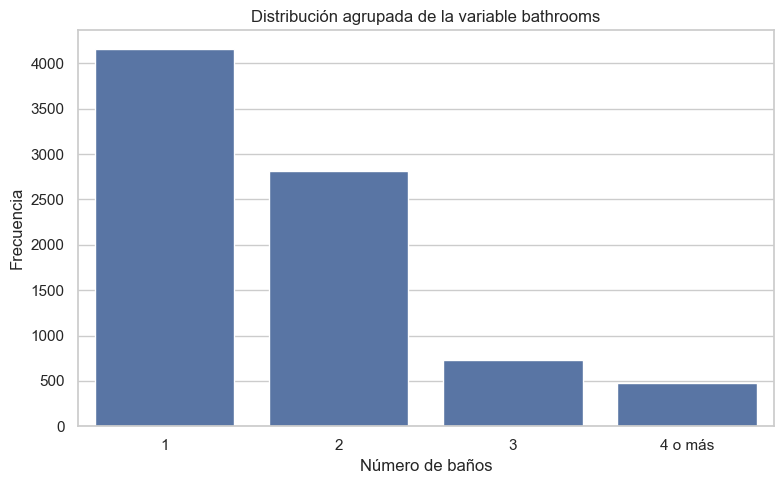

In [245]:
df_plot = df.copy()

df_plot["bathrooms_agrupado"] = df_plot["bathrooms"].apply(
    lambda x: "4 o más" if x >= 4 else str(int(x))
)

orden_bathrooms = ["1", "2", "3", "4 o más"]

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_plot,
    x="bathrooms_agrupado",
    order=orden_bathrooms
)

plt.title("Distribución agrupada de la variable bathrooms")
plt.xlabel("Número de baños")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

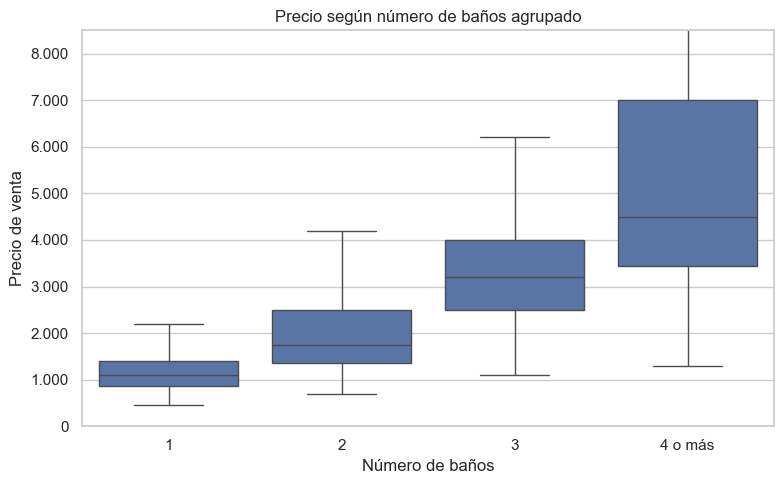

In [246]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

df_plot = df.copy()

df_plot["bathrooms_agrupado"] = df_plot["bathrooms"].apply(
    lambda x: "4 o más" if x >= 4 else str(int(x))
)

orden_bathrooms = ["1", "2", "3", "4 o más"]

limite_precio = df["price"].quantile(0.99)

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_plot,
    x="bathrooms_agrupado",
    y="price",
    order=orden_bathrooms,
    showfliers=False
)

plt.ylim(0, limite_precio)

plt.title("Precio según número de baños agrupado")
plt.xlabel("Número de baños")
plt.ylabel("Precio de venta")

plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", "."))
)

plt.tight_layout()
plt.show()

### Variables categóricas vs precio

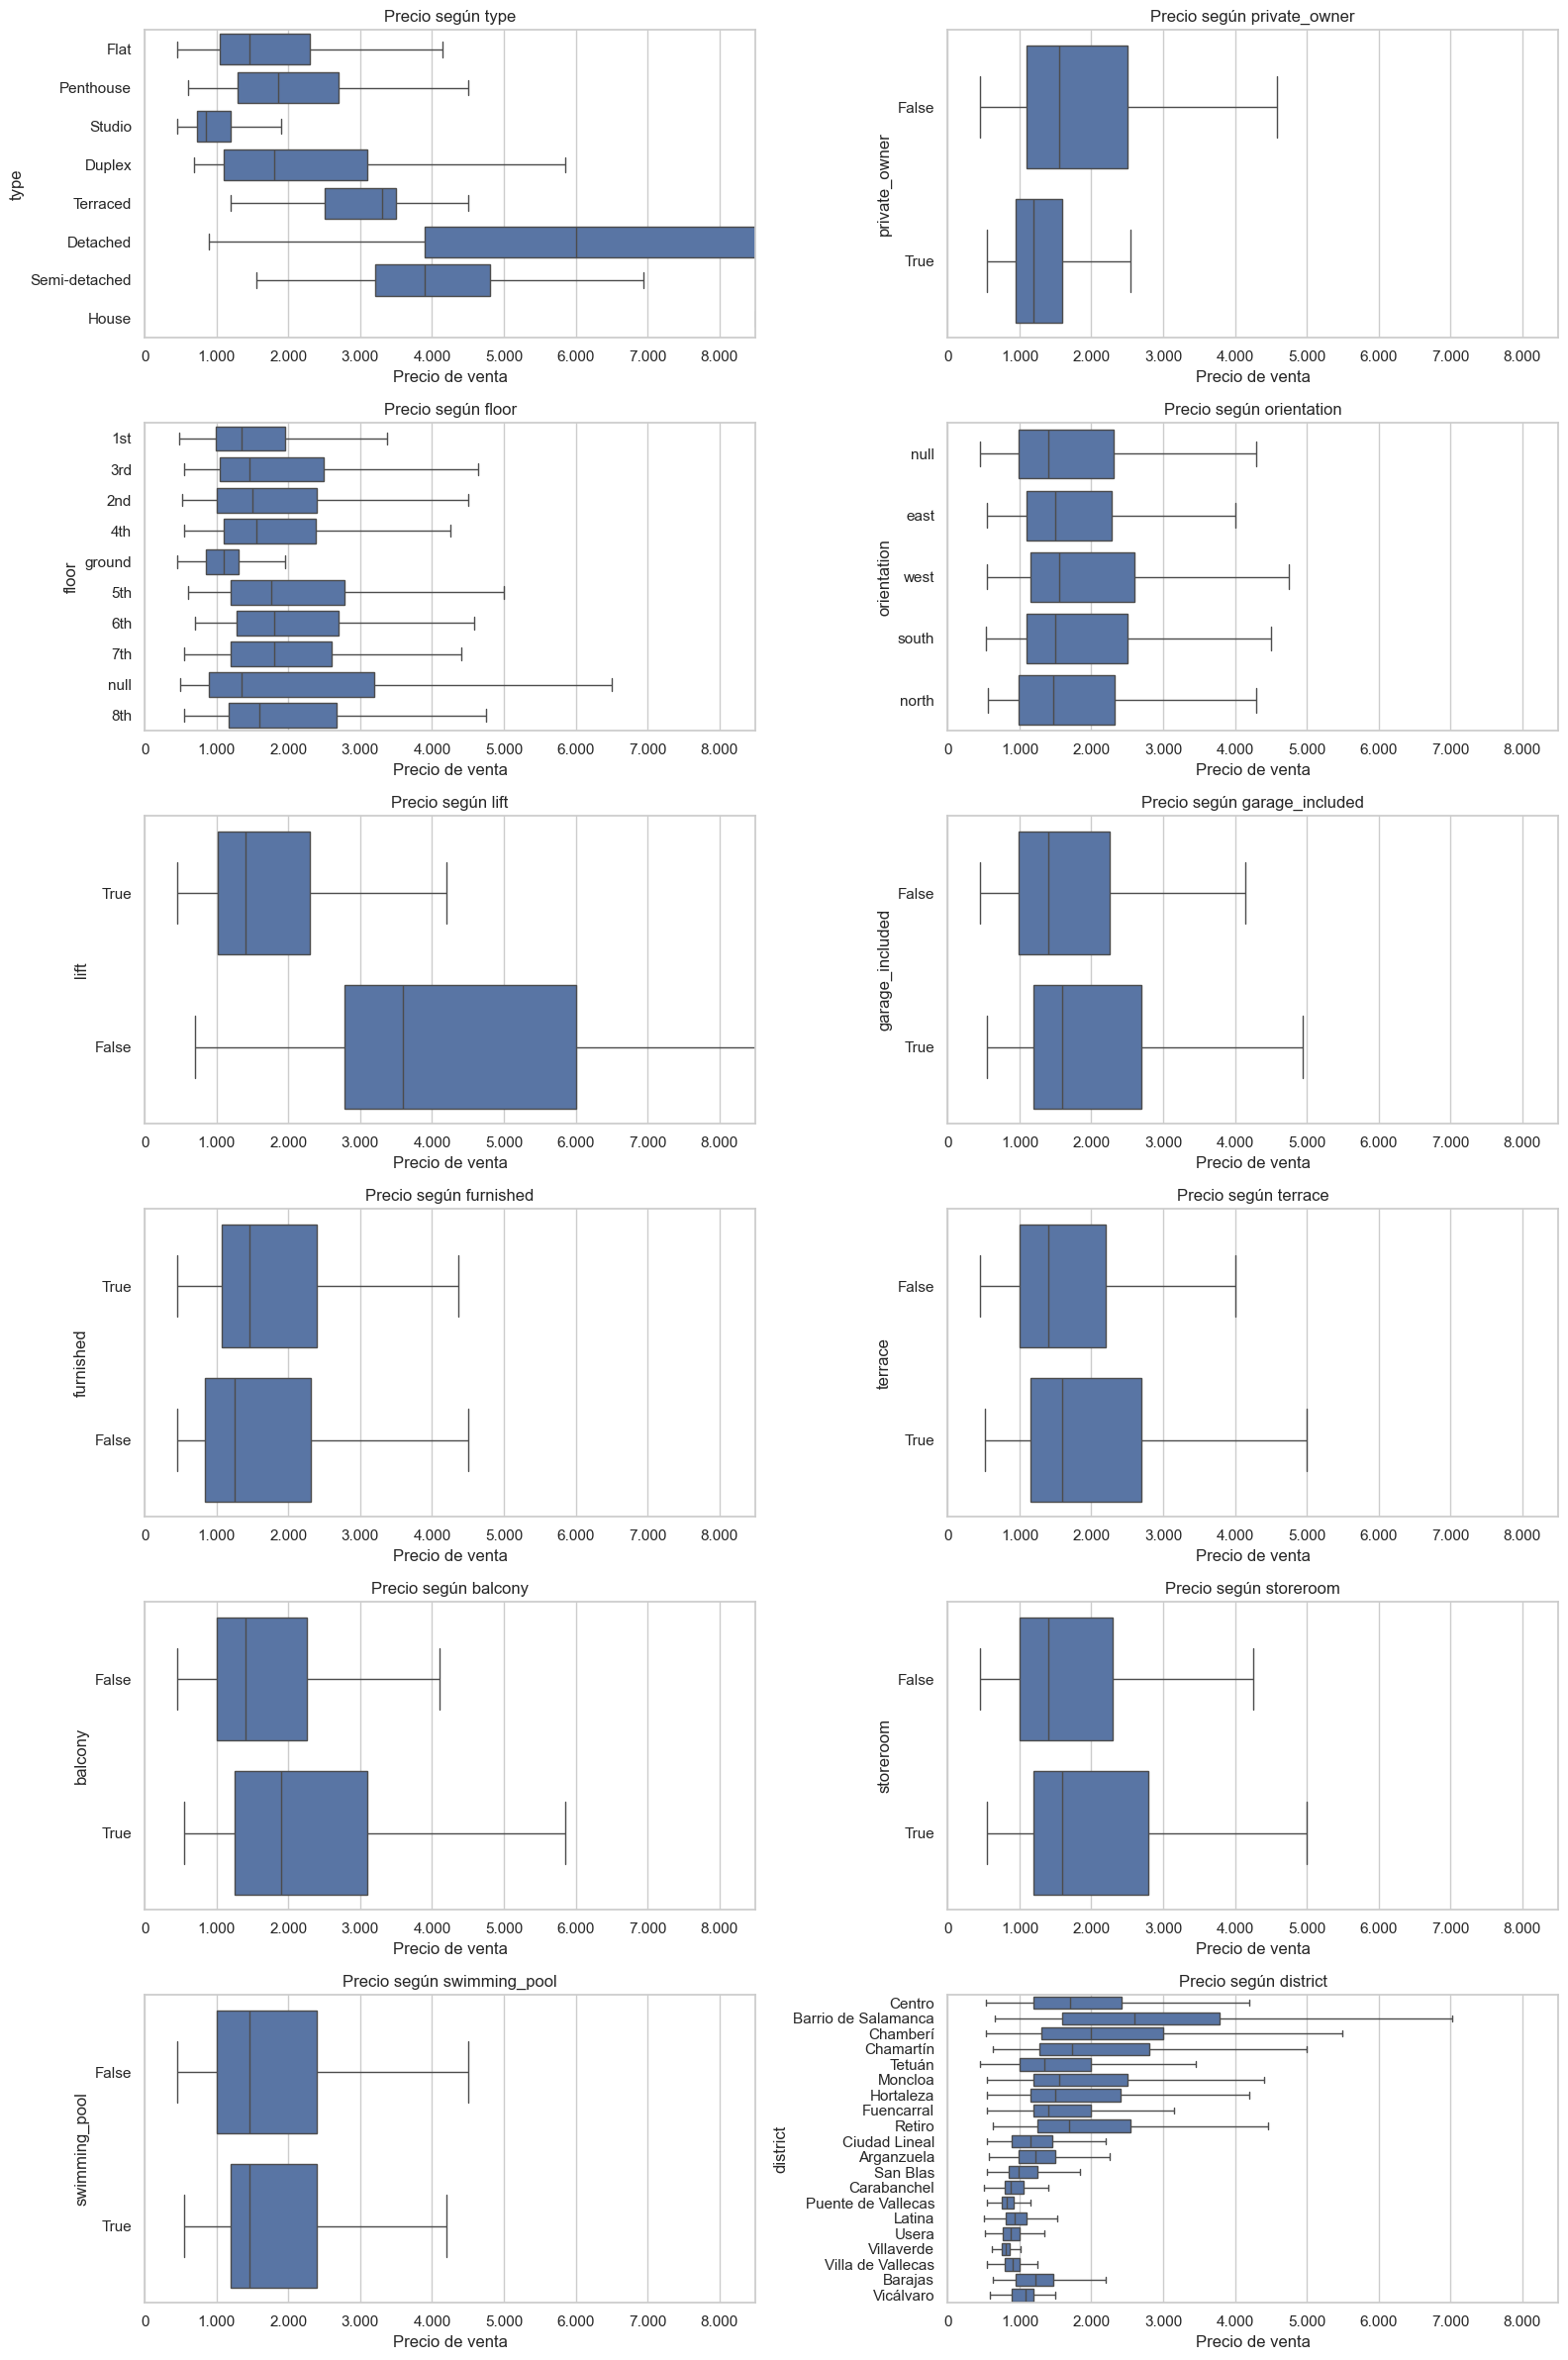

In [247]:
import math
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

df_plot = df.copy()

variables_excluir = [
    "postalcode",
    "garden_area",
    "second_hand",
    "professional_name"
]

variables_categoricas_plot = [
    col for col in variables_categoricas
    if col not in variables_excluir
]

for col in variables_categoricas_plot:
    df_plot[col] = df_plot[col].fillna("null").astype(str)

limite_precio = df_plot["price"].quantile(0.99)

n_vars = len(variables_categoricas_plot)
n_cols = 2
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(variables_categoricas_plot):
    
    if col == "district":
        categorias = df_plot[col].value_counts().head(20).index
    else:
        categorias = df_plot[col].value_counts().head(10).index

    datos_col = df_plot[df_plot[col].isin(categorias)]
    
    sns.boxplot(
        data=datos_col,
        x="price",
        y=col,
        order=categorias,
        ax=axes[i],
        showfliers=False
    )
    
    axes[i].set_title(f"Precio según {col}")
    axes[i].set_xlabel("Precio de venta")
    axes[i].set_ylabel(col)

    axes[i].set_xlim(0, limite_precio)

    axes[i].xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", "."))
    )

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Análisis del precio por distrito

In [248]:
precio_por_distrito = (
    df.groupby("district")["price"]
    .agg(
        numero_viviendas="count",
        precio_medio="mean",
        precio_mediano="median"
    )
    .sort_values("precio_mediano", ascending=False)
)

display(precio_por_distrito.head(20))

,numero_viviendas,precio_medio,precio_mediano
district,,,
Barrio de Salamanca,1113,"3.060,27","2.600,00"
Chamberí,771,"2.375,12","2.000,00"
Chamartín,742,"2.310,20","1.732,50"
Centro,1274,"2.007,14","1.705,00"
Retiro,428,"2.178,68","1.690,00"
Moncloa,446,"2.139,07","1.550,00"
Hortaleza,432,"2.124,10","1.500,00"
Fuencarral,430,"1.667,60","1.400,00"
Tetuán,586,"1.558,09","1.350,00"


### Matriz de correlación

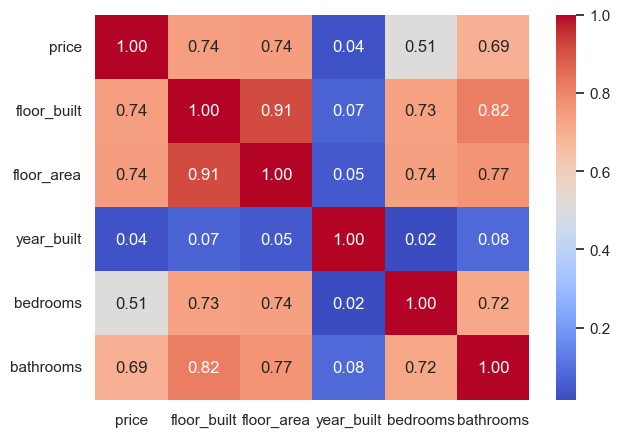

In [249]:
corr = df[variables_numericas].corr()

plt.figure(figsize=(7, 5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.show()

In [250]:
df["price_m2"] = df["price"] / df["floor_built"]

df["price_m2"] = df["price_m2"].replace([np.inf, -np.inf], np.nan)

df["price_m2"].describe()

count   8.171,00
mean       20,15
std         9,28
min         4,50
25%        13,98
50%        17,55
75%        23,33
max       120,00
Name: price_m2, dtype: float64

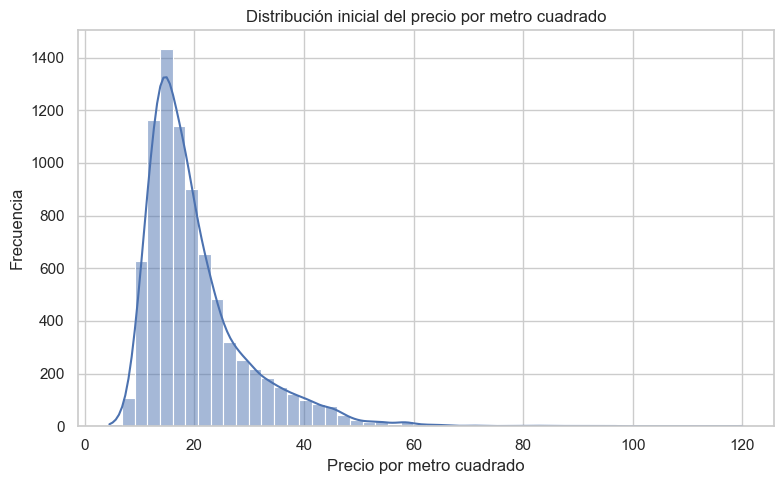

In [251]:
import matplotlib.ticker as mticker

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="price_m2",
    bins=50,
    kde=True
)

plt.title("Distribución inicial del precio por metro cuadrado")
plt.xlabel("Precio por metro cuadrado")
plt.ylabel("Frecuencia")

plt.gca().xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", "."))
)

plt.tight_layout()
plt.show()

In [252]:
precio_m2_por_distrito = (
    df.groupby("district")["price_m2"]
    .agg(
        numero_viviendas="count",
        precio_m2_medio="mean",
        precio_m2_mediano="median"
    )
    .sort_values("precio_m2_mediano", ascending=False)
)

display(precio_m2_por_distrito.head(20))

,numero_viviendas,precio_m2_medio,precio_m2_mediano
district,,,
Centro,1274,"26,31","23,54"
Barrio de Salamanca,1113,"25,48","22,45"
Chamberí,771,"23,30","21,00"
Tetuán,586,"20,75","18,38"
Retiro,428,"20,71","18,25"
Chamartín,742,"19,28","17,41"
Arganzuela,314,"18,64","16,81"
Moncloa,445,"18,42","15,82"
Ciudad Lineal,414,"15,56","14,84"


# Preprocesamiento e ingeniería de características

In [253]:
df_pre = df.copy()

print("Dimensiones antes del preprocesamiento:", df_pre.shape)

Dimensiones antes del preprocesamiento: (8176, 25)


## Eliminación de duplicados

In [254]:
filas_antes = df_pre.shape[0]

df_pre = df_pre.drop_duplicates()

filas_despues = df_pre.shape[0]

print("Duplicados eliminados:", filas_antes - filas_despues)
print("Dimensiones:", df_pre.shape)

Duplicados eliminados: 61
Dimensiones: (8115, 25)


## Tratamiento de valores inválidos en la variable target

In [255]:
filas_antes = df_pre.shape[0]

df_pre = df_pre[df_pre["price"].notna()]
df_pre = df_pre[df_pre["price"] > 0]

filas_despues = df_pre.shape[0]

print("Registros eliminados por precio nulo o inválido:", filas_antes - filas_despues)
print("Dimensiones:", df_pre.shape)

Registros eliminados por precio nulo o inválido: 0
Dimensiones: (8115, 25)


## Tratamiento de nulos

In [256]:
import pandas as pd

df_pre = df.copy()

nulos_antes = df_pre.isna().sum()

# Columnas eliminadas por alto porcentaje de nulos o por que aportan poco valor
columnas_eliminar = [
    "floor_area",
    "year_built",
    "orientation",
    "professional_name"
]

# Eliminar también garden_area porque solo tiene un valor único
columnas_eliminar.append("garden_area")

df_pre = df_pre.drop(columns=columnas_eliminar)

# Tratamiento de nulos restantes

# floor: pocos nulos, se crea categoría explícita
df_pre["floor"] = df_pre["floor"].fillna("Desconocido")

# postalcode: se trata como categórica
df_pre["postalcode"] = df_pre["postalcode"].fillna("Desconocido")
df_pre["postalcode"] = df_pre["postalcode"].astype(str)
df_pre["postalcode"] = df_pre["postalcode"].str.replace(".0", "", regex=False)

nulos_despues = df_pre.isna().sum()

resumen_nulos = pd.DataFrame({
    "Nulos antes": nulos_antes,
    "Nulos después": nulos_despues,
    "Nulos tratados": nulos_antes - nulos_despues
})

resumen_nulos["% nulos después"] = (
    resumen_nulos["Nulos después"] / len(df_pre) * 100
).round(2)

resumen_nulos = resumen_nulos.fillna(0)

display(resumen_nulos)

,Nulos antes,Nulos después,Nulos tratados,% nulos después
balcony,0,"0,00","0,00","0,00"
bathrooms,0,"0,00","0,00","0,00"
bedrooms,0,"0,00","0,00","0,00"
district,0,"0,00","0,00","0,00"
floor,249,"0,00","249,00","0,00"
floor_area,4700,"0,00","0,00","0,00"
floor_built,0,"0,00","0,00","0,00"
furnished,0,"0,00","0,00","0,00"
garage_included,0,"0,00","0,00","0,00"
garden_area,0,"0,00","0,00","0,00"


## Transformación y creación de nuevas variables

### Transformación de la variable planta a numérica

In [257]:
import re

def transformar_planta(valor):
    if pd.isna(valor):
        return np.nan
    
    valor = str(valor).lower().strip()
    
    if valor == "ground":
        return 0
    
    if valor == "floor":
        return np.nan
    
    if "," in valor:
        return np.nan
    
    match = re.search(r"\d+", valor)
    
    if match:
        planta = int(match.group())
        
        if planta > 55:
            return np.nan
        
        return planta
    
    return np.nan

df_pre["floor_numeric"] = df_pre["floor"].apply(transformar_planta)

In [258]:
df_pre.columns

Index(['title', 'type', 'price', 'private_owner', 'floor_built', 'floor',
       'bedrooms', 'bathrooms', 'second_hand', 'lift', 'garage_included',
       'furnished', 'terrace', 'balcony', 'storeroom', 'swimming_pool',
       'location', 'district', 'postalcode', 'price_m2', 'floor_numeric'],
      dtype='str')

## Tratamiento de outliers

Función de eliminación de outliers

In [259]:
def filtrar_percentiles(dataframe, columna, p_inf=0.01, p_sup=0.99):
    q_inf = dataframe[columna].quantile(p_inf)
    q_sup = dataframe[columna].quantile(p_sup)
    
    dataframe_filtrado = dataframe[
        (dataframe[columna] >= q_inf) &
        (dataframe[columna] <= q_sup)
    ].copy()
    
    return dataframe_filtrado, q_inf, q_sup

Aplicar función a los datos

In [260]:
filas_antes_outliers = df_pre.shape[0]

df_pre, price_inf, price_sup = filtrar_percentiles(
    df_pre, "price", 0.01, 0.99
)

df_pre, floor_built_inf, floor_built_sup = filtrar_percentiles(
    df_pre, "floor_built", 0.01, 0.99
)


df_pre, floor_inf, floor_sup = filtrar_percentiles(
    df_pre, "floor_numeric", 0.01, 0.99
)

filas_despues_outliers = df_pre.shape[0]

print("Filas antes del tratamiento de outliers:", filas_antes_outliers)
print("Filas después del tratamiento de outliers:", filas_despues_outliers)
print("Observaciones eliminadas:", filas_antes_outliers - filas_despues_outliers)

print("\nLímites aplicados:")
print(f"Price: {price_inf:.2f} - {price_sup:.2f}")
print(f"Floor built: {floor_built_inf:.2f} - {floor_built_sup:.2f}")
print(f"Floor numeric: {floor_inf:.2f} - {floor_sup:.2f}")

Filas antes del tratamiento de outliers: 8176
Filas después del tratamiento de outliers: 7424
Observaciones eliminadas: 752

Límites aplicados:
Price: 650.00 - 8500.00
Floor built: 29.00 - 366.00
Floor numeric: 0.00 - 18.00


Tabla resumen de outliers

In [261]:
tabla_outliers = pd.DataFrame({
    "Variable": [
        "Precio del alquiler",
        "Superficie construida",
        "Planta numérica"
    ],
    "Percentil inferior": [price_inf, floor_built_inf, floor_inf],
    "Percentil superior": [price_sup, floor_built_sup, floor_sup],
    "Criterio aplicado": ["P1-P99", "P1-P99", "P1-P99"]
})

display(tabla_outliers.round(2))

,Variable,Percentil inferior,Percentil superior,Criterio aplicado
0,Precio del alquiler,"650,00","8.500,00",P1-P99
1,Superficie construida,"29,00","366,00",P1-P99
2,Planta numérica,"0,00","18,00",P1-P99


### Transformación logarítmica del precio

In [262]:
df_pre["log_precio"] = np.log1p(df_pre["price"])

## Exploración posterior al preprocesamiento

In [263]:
tabla_comparacion = pd.DataFrame({
    "Fase": ["Antes del preprocesamiento", "Después del preprocesamiento"],
    "Observaciones": [df.shape[0], df_pre.shape[0]],
    "Variables": [df.shape[1], df_pre.shape[1]],
    "Nulos totales": [df.isna().sum().sum(), df_pre.isna().sum().sum()],
    "Precio mínimo": [df["price"].min(), df_pre["price"].min()],
    "Precio máximo": [df["price"].max(), df_pre["price"].max()],
    "Superficie mínima": [df["floor_built"].min(), df_pre["floor_built"].min()],
    "Superficie máxima": [df["floor_built"].max(), df_pre["floor_built"].max()]
})

display(tabla_comparacion)

,Fase,Observaciones,Variables,Nulos totales,Precio mínimo,Precio máximo,Superficie mínima,Superficie máxima
0,Antes del preprocesamiento,8176,25,18542,450,25000,0,990
1,Después del preprocesamiento,7424,22,0,650,8500,29,366


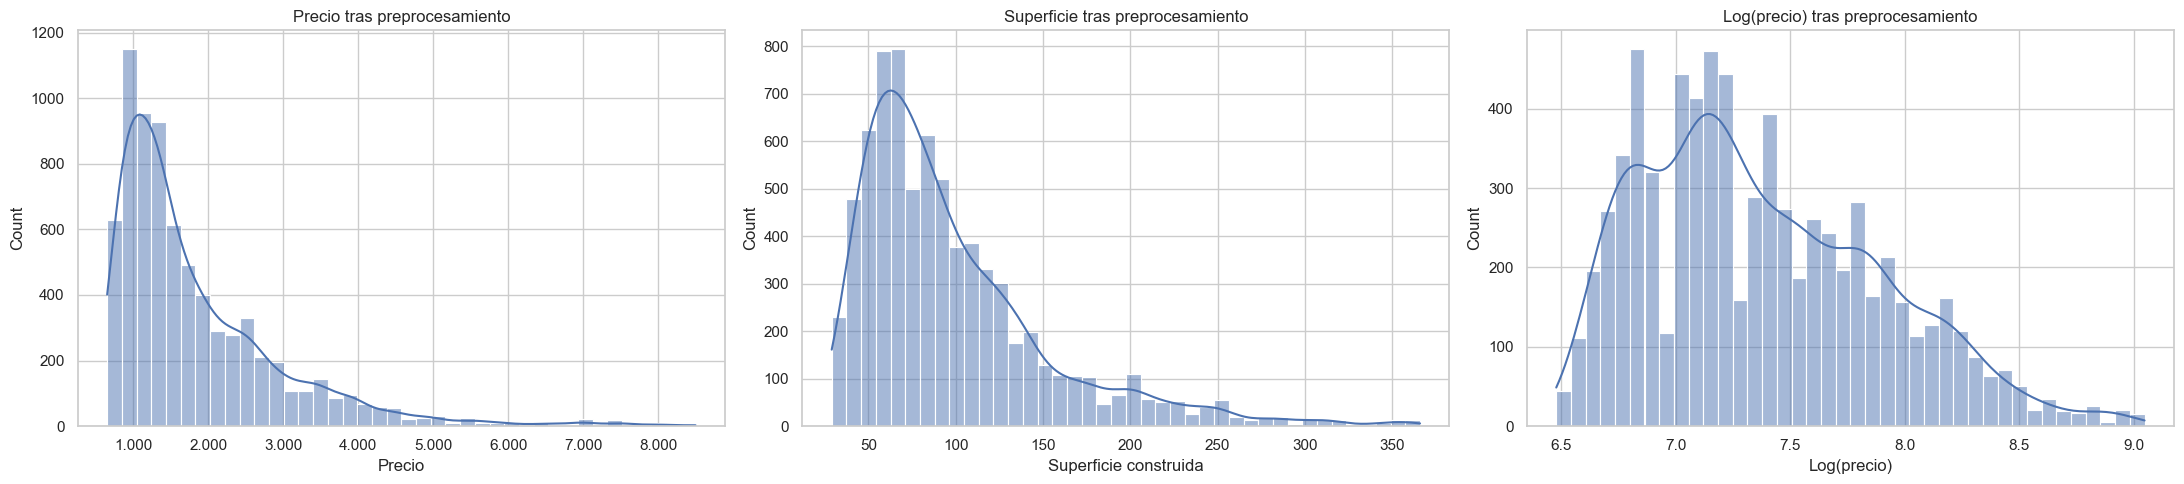

In [264]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import numpy as np


fig, axes = plt.subplots(1, 3, figsize=(22, 5))

sns.histplot(df_pre["price"], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Precio tras preprocesamiento")
axes[0].set_xlabel("Precio")
axes[0].xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", "."))
)

sns.histplot(df_pre["floor_built"], bins=40, kde=True, ax=axes[1])
axes[1].set_title("Superficie tras preprocesamiento")
axes[1].set_xlabel("Superficie construida")

sns.histplot(df_pre["log_precio"], bins=40, kde=True, ax=axes[2])
axes[2].set_title("Log(precio) tras preprocesamiento")
axes[2].set_xlabel("Log(precio)")

plt.tight_layout()
plt.show()

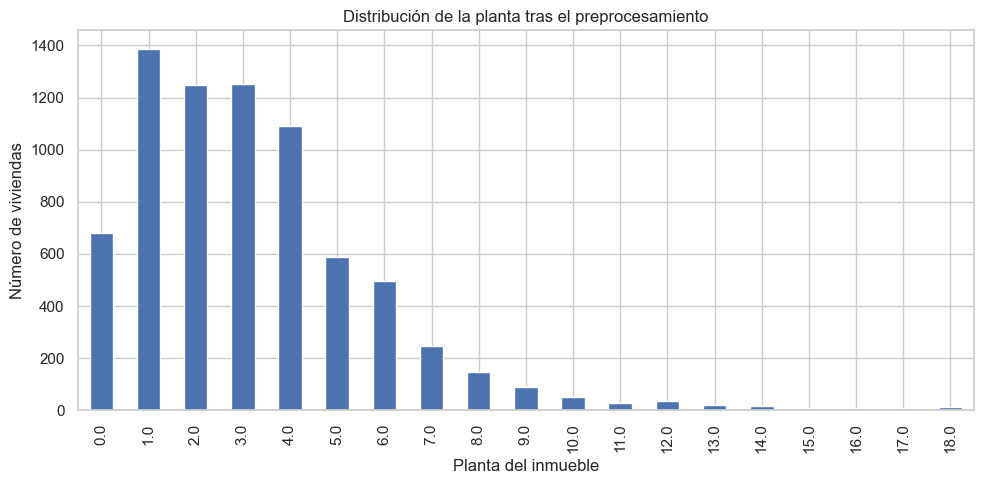

In [265]:
plt.figure(figsize=(10, 5))

df_pre["floor_numeric"].value_counts(dropna=False).sort_index().plot(kind="bar")

plt.title("Distribución de la planta tras el preprocesamiento")
plt.xlabel("Planta del inmueble")
plt.ylabel("Número de viviendas")

plt.tight_layout()
plt.show()

## Selección de variables

In [266]:
numeric_features = [
    "floor_built",
    "bedrooms",
    "floor_numeric"
]

categorical_features = [
    "type",
    "private_owner",
    "second_hand",
    "lift",
    "garage_included",
    "furnished",
    "terrace",
    "balcony",
    "storeroom",
    "swimming_pool",
    "district"
]

features = numeric_features + categorical_features

target = "log_precio"

X = df_pre[features].copy()
y = df_pre[target].copy()

# Asegurar tipos numéricos
for col in numeric_features:
    X[col] = pd.to_numeric(X[col], errors="coerce")

# Asegurar categóricas como texto
for col in categorical_features:
    X[col] = X[col].astype("object").astype(str)

# Minería de datos

## División train/test

In [267]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5939, 14)
X_test: (1485, 14)
y_train: (5939,)
y_test: (1485,)


## Métricas de evaluación

In [268]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

Función para calcular las métricas

In [269]:
def calcular_metricas(y_real, y_pred, target_log=False):
    if target_log:
        y_real_eval = np.expm1(y_real)
        y_pred_eval = np.expm1(y_pred)
    else:
        y_real_eval = y_real
        y_pred_eval = y_pred
    
    mae = mean_absolute_error(y_real_eval, y_pred_eval)
    mse = mean_squared_error(y_real_eval, y_pred_eval)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_real_eval, y_pred_eval) * 100
    r2 = r2_score(y_real_eval, y_pred_eval)
    
    return mae, mse, rmse, mape, r2

Función para evaluar modelo

In [270]:
def evaluar_modelo(nombre, modelo, X_train, X_test, y_train, y_test):
    modelo.fit(X_train, y_train)
    
    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)
    
    mae_train, mse_train, rmse_train, mape_train, r2_train = calcular_metricas(
        y_train,
        y_pred_train
    )
    
    mae_test, mse_test, rmse_test, mape_test, r2_test = calcular_metricas(
        y_test,
        y_pred_test
    )
    
    return {
        "Modelo": nombre,
        "MAE_train": mae_train,
        "MSE_train": mse_train,
        "RMSE_train": rmse_train,
        "MAPE_train": mape_train,
        "R2_train": r2_train,
        "MAE_test": mae_test,
        "MSE_test": mse_test,
        "RMSE_test": rmse_test,
        "MAPE_test": mape_test,
        "R2_test": r2_test
    }

## Pipelines de preprocesamiento (escalado)

In [271]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_features = [
    "floor_built",
    "bedrooms",
    "floor_numeric"
]

categorical_features = [
    "private_owner",
    "second_hand",
    "lift",
    "garage_included",
    "furnished",
    "terrace",
    "balcony",
    "storeroom",
    "swimming_pool",
    "district"
]

Pipeline con escalado para los algoritmos: Regresión lineal, LASSO, ElasticNet, SVR, KNN y ANN

In [272]:
numeric_transformer_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Desconocido")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_scaled, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Pipeline sin escalado para algoritmos basados en árboles

In [273]:
numeric_transformer_no_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor_no_scaled = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_no_scaled, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Importar modelos

In [274]:
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

Modelos base

In [275]:
modelos_base = {
    "Regresión lineal": Pipeline(steps=[
        ("preprocessor", preprocessor_scaled),
        ("model", LinearRegression())
    ]),
    
    "LASSO": Pipeline(steps=[
        ("preprocessor", preprocessor_scaled),
        ("model", Lasso(
            alpha=0.001,
            max_iter=10000,
            random_state=42
        ))
    ]),
    
    "ElasticNet": Pipeline(steps=[
        ("preprocessor", preprocessor_scaled),
        ("model", ElasticNet(
            alpha=0.001,
            l1_ratio=0.5,
            max_iter=10000,
            random_state=42
        ))
    ]),
    
    "SVR": Pipeline(steps=[
        ("preprocessor", preprocessor_scaled),
        ("model", SVR())
    ]),
    
    "KNN": Pipeline(steps=[
        ("preprocessor", preprocessor_scaled),
        ("model", KNeighborsRegressor())
    ]),
    
    "Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor_no_scaled),
        ("model", RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ]),
    
    "XGBoost": Pipeline(steps=[
        ("preprocessor", preprocessor_no_scaled),
        ("model", XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        ))
    ]),
    
    "CatBoost": Pipeline(steps=[
        ("preprocessor", preprocessor_no_scaled),
        ("model", CatBoostRegressor(
            iterations=300,
            learning_rate=0.05,
            depth=6,
            loss_function="RMSE",
            random_seed=42,
            verbose=0
        ))
    ]),
    
    "ANN": Pipeline(steps=[
        ("preprocessor", preprocessor_scaled),
        ("model", MLPRegressor(
            hidden_layer_sizes=(128, 64),
            activation="relu",
            solver="adam",
            alpha=0.0001,
            learning_rate_init=0.001,
            max_iter=500,
            early_stopping=True,
            random_state=42
        ))
    ])
}

## Entrenamiento y evaluación de modelos

Entrenamiento y evaluación inicial (con validación cruzada con k=5)

In [276]:
from sklearn.model_selection import KFold
from sklearn.base import clone

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

target_log=True

resultados_cv = []
resultados_cv_folds = []

for nombre, modelo in modelos_base.items():
    print(f"Validación cruzada para {nombre}...")
    
    metricas_folds = []
    
    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train), start=1):
        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]
        
        modelo_fold = clone(modelo)
        modelo_fold.fit(X_tr, y_tr)
        
        y_pred_val = modelo_fold.predict(X_val)
        
        mae, mse, rmse, mape, r2 = calcular_metricas(
            y_val,
            y_pred_val,
            target_log=target_log
        )
        
        metricas_fold = {
            "Modelo": nombre,
            "Fold": fold,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "MAPE": mape,
            "R2": r2
        }
        
        metricas_folds.append(metricas_fold)
        resultados_cv_folds.append(metricas_fold)
    
    metricas_folds_df = pd.DataFrame(metricas_folds)
    
    resultados_cv.append({
        "Modelo": nombre,
        "MAE": metricas_folds_df["MAE"].mean(),
        "MSE": metricas_folds_df["MSE"].mean(),
        "RMSE": metricas_folds_df["RMSE"].mean(),
        "MAPE": metricas_folds_df["MAPE"].mean(),
        "R2": metricas_folds_df["R2"].mean()
    })

resultados_cv_df = pd.DataFrame(resultados_cv)
resultados_cv_df = resultados_cv_df.sort_values("RMSE")

display(resultados_cv_df.round(4))

Validación cruzada para Regresión lineal...
Validación cruzada para LASSO...
Validación cruzada para ElasticNet...
Validación cruzada para SVR...
Validación cruzada para KNN...
Validación cruzada para Random Forest...
Validación cruzada para XGBoost...
Validación cruzada para CatBoost...
Validación cruzada para ANN...


,Modelo,MAE,MSE,RMSE,MAPE,R2
6,XGBoost,"378,49","353.165,26","593,54","19,53","0,73"
5,Random Forest,"372,31","360.376,44","599,48","19,67","0,73"
7,CatBoost,"395,11","374.471,11","610,86","20,12","0,72"
3,SVR,"390,38","380.590,79","615,98","19,52","0,71"
8,ANN,"404,00","389.412,81","622,97","20,78","0,70"
4,KNN,"435,56","448.845,18","669,45","23,35","0,66"
0,Regresión lineal,"427,34","453.533,52","672,68","21,61","0,65"
2,ElasticNet,"429,04","460.177,14","677,59","21,66","0,65"
1,LASSO,"431,38","465.920,71","681,83","21,81","0,65"


Gráficos de comparación de modelos

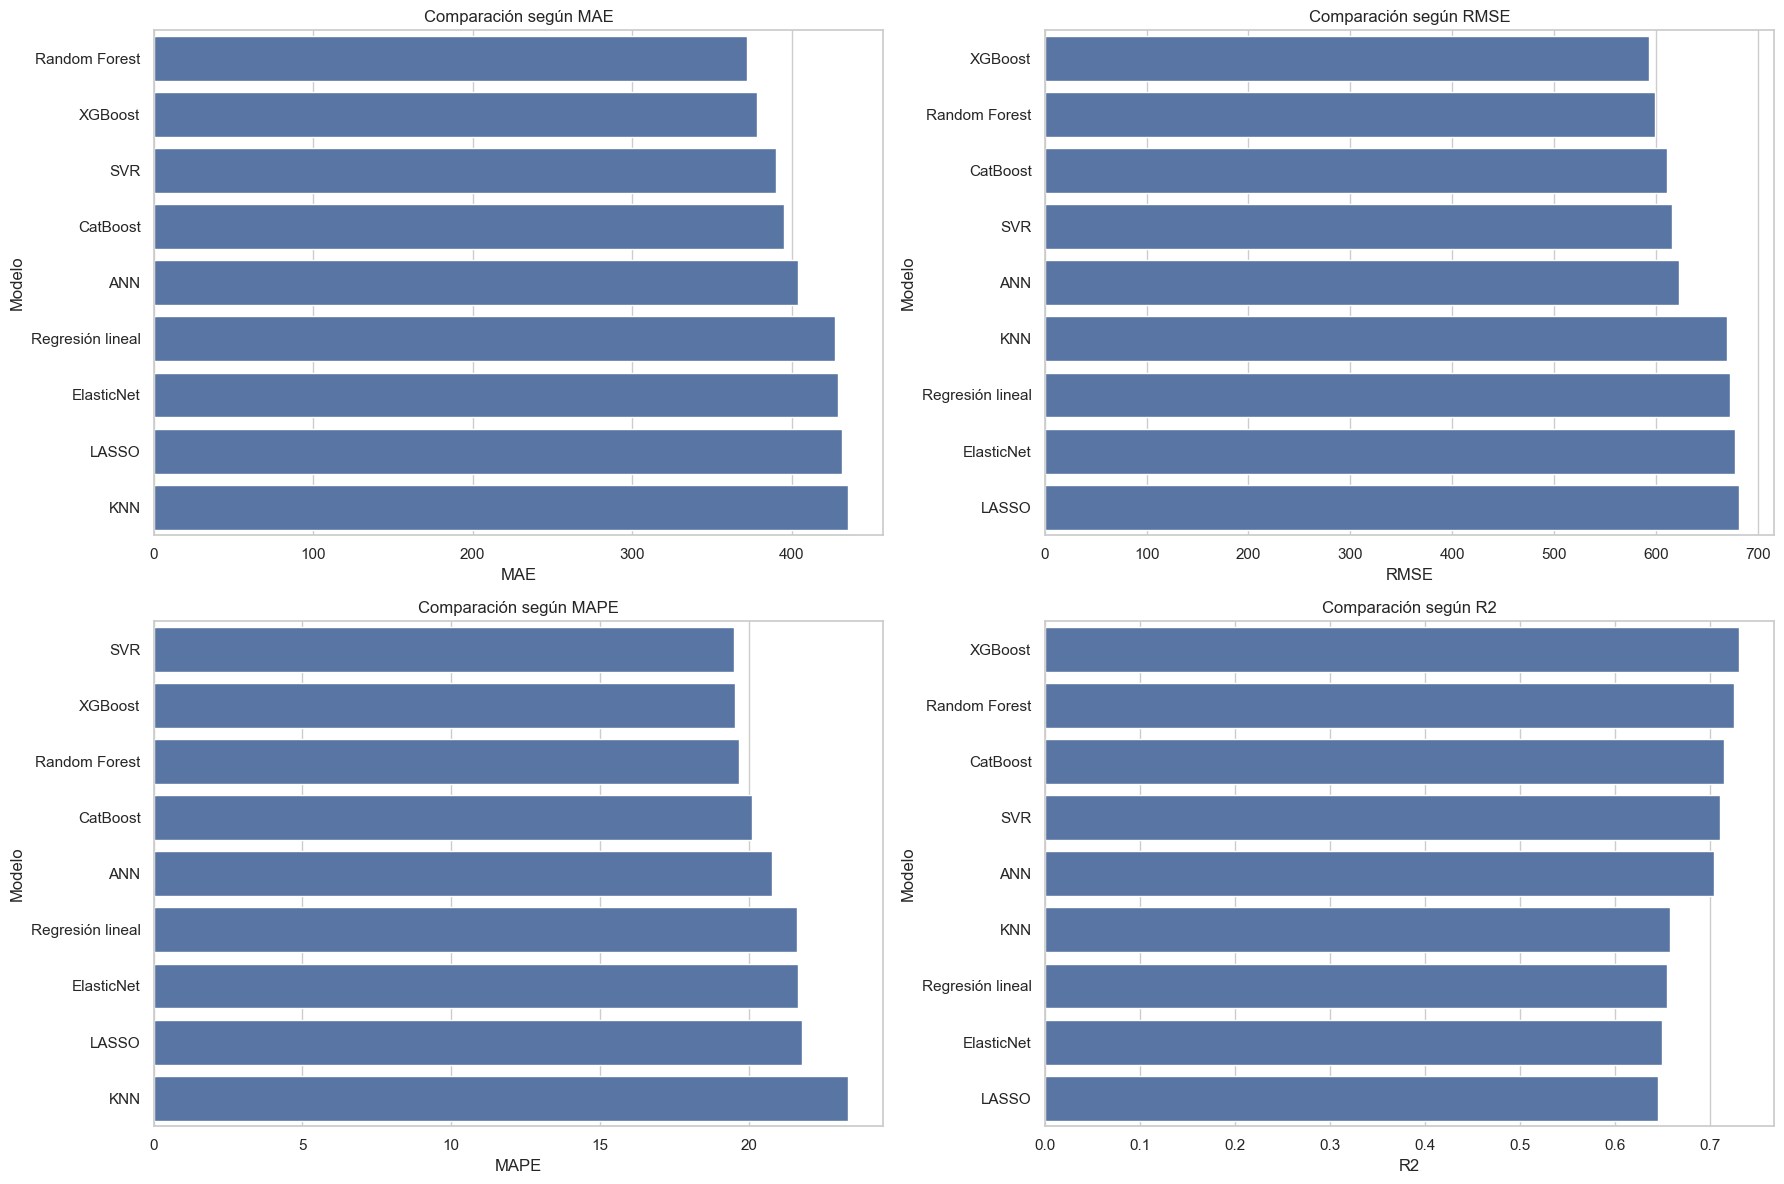

In [279]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

metricas = [
    ("MAE", True),
    ("RMSE", True),
    ("MAPE", True),
    ("R2", False)
]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for ax, (metrica, menor_es_mejor) in zip(axes, metricas):
    
    datos_ordenados = resultados_cv_df.sort_values(
        metrica,
        ascending=menor_es_mejor
    )
    
    sns.barplot(
        data=datos_ordenados,
        x=metrica,
        y="Modelo",
        ax=ax
    )
    
    ax.set_title(f"Comparación según {metrica}")
    ax.set_xlabel(metrica)
    ax.set_ylabel("Modelo")
    
    if metrica in ["MAE", "RMSE"]:
        ax.xaxis.set_major_formatter(
            ticker.FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", "."))
        )

plt.tight_layout()
plt.show()

## Selección del mejor modelo y optimización de hiperparámetros con Randomized o Grid Search

In [280]:
top_modelos = resultados_cv_df.head(3)["Modelo"].tolist()

print("Modelos seleccionados para ajuste de hiperparámetros:")
print(top_modelos)

Modelos seleccionados para ajuste de hiperparámetros:
['XGBoost', 'Random Forest', 'CatBoost']


Optimización de hiperparámetros

In [281]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

Random Forest

In [282]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_no_scaled),
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

rf_param_grid = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}

XGBoost

In [283]:
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_no_scaled),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_param_grid = {
    "model__n_estimators": [200, 300, 500],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 5, 7],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0]
}

CatBoost

In [284]:
cat_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_no_scaled),
    ("model", CatBoostRegressor(
        loss_function="RMSE",
        random_seed=42,
        verbose=0
    ))
])

cat_param_grid = {
    "model__iterations": [200, 300, 500],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__depth": [4, 6, 8],
    "model__l2_leaf_reg": [1, 3, 5, 7]
}

In [285]:
busquedas = {
    "Random Forest": {
        "pipeline": rf_pipeline,
        "param_grid": rf_param_grid,
        "tipo": "random",
        "n_iter": 20
    },
    "XGBoost": {
        "pipeline": xgb_pipeline,
        "param_grid": xgb_param_grid,
        "tipo": "random",
        "n_iter": 20
    },
    "CatBoost": {
        "pipeline": cat_pipeline,
        "param_grid": cat_param_grid,
        "tipo": "random",
        "n_iter": 20
    }
}

In [289]:
modelos_ajustados = {}
resultados_ajuste = []

for nombre in top_modelos:
    print(f"\nAjustando hiperparámetros para {nombre}...")
    
    config = busquedas[nombre]
    
    if config["tipo"] == "grid":
        search = GridSearchCV(
            estimator=config["pipeline"],
            param_grid=config["param_grid"],
            cv=5,
            scoring="neg_root_mean_squared_error",
            n_jobs=-1
        )
    else:
        search = RandomizedSearchCV(
            estimator=config["pipeline"],
            param_distributions=config["param_grid"],
            n_iter=config["n_iter"],
            cv=5,
            scoring="neg_root_mean_squared_error",
            random_state=42,
            n_jobs=-1
        )
    
    search.fit(X_train, y_train)
    
    modelos_ajustados[nombre] = search.best_estimator_
    
    resultados_ajuste.append({
        "Modelo": nombre,
        "Mejor_RMSE_CV": -search.best_score_,
        "Mejores_hiperparametros": search.best_params_
    })

resultados_ajuste_df = pd.DataFrame(resultados_ajuste)
resultados_ajuste_df = resultados_ajuste_df.sort_values("Mejor_RMSE_CV")

with pd.option_context('display.max_colwidth', None):
    display(resultados_ajuste_df)


Ajustando hiperparámetros para XGBoost...

Ajustando hiperparámetros para Random Forest...

Ajustando hiperparámetros para CatBoost...


,Modelo,Mejor_RMSE_CV,Mejores_hiperparametros
2,CatBoost,"0,26","{'model__learning_rate': 0.1, 'model__l2_leaf_reg': 1, 'model__iterations': 500, 'model__depth': 6}"
0,XGBoost,"0,26","{'model__subsample': 0.8, 'model__n_estimators': 200, 'model__max_depth': 7, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.8}"
1,Random Forest,"0,26","{'model__n_estimators': 500, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': None}"


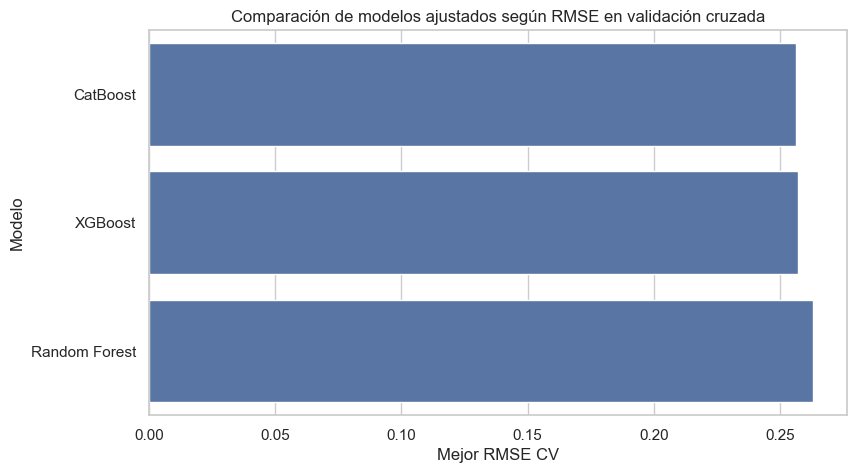

In [293]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=resultados_ajuste_df,
    x="Mejor_RMSE_CV",
    y="Modelo"
)

plt.title("Comparación de modelos ajustados según RMSE en validación cruzada")
plt.xlabel("Mejor RMSE CV")
plt.ylabel("Modelo")
plt.show()

In [294]:
mejor_modelo_nombre = resultados_ajuste_df.iloc[0]["Modelo"]
mejor_modelo = modelos_ajustados[mejor_modelo_nombre]

print("Mejor modelo ajustado según CV:", mejor_modelo_nombre)

Mejor modelo ajustado según CV: CatBoost


Entrenamiento del mejor modelo

In [295]:
mejor_modelo.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [292]:
y_pred_test = mejor_modelo.predict(X_test)

mae, mse, rmse, mape, r2 = calcular_metricas(
    y_test,
    y_pred_test,
    target_log=target_log
)

resultado_test_final = pd.DataFrame({
    "Modelo": [mejor_modelo_nombre],
    "MAE_test": [mae],
    "MSE_test": [mse],
    "RMSE_test": [rmse],
    "MAPE_test": [mape],
    "R2_test": [r2]
})

display(resultado_test_final.round(4))

,Modelo,MAE_test,MSE_test,RMSE_test,MAPE_test,R2_test
0,CatBoost,"376,62","373.053,05","610,78","19,40","0,72"


# Interpretabilidad

In [296]:
preprocessor_fitted = mejor_modelo.named_steps["preprocessor"]
modelo_fitted = mejor_modelo.named_steps["model"]

print(type(preprocessor_fitted))
print(type(modelo_fitted))

<class 'sklearn.compose._column_transformer.ColumnTransformer'>
<class 'catboost.core.CatBoostRegressor'>


In [297]:
def obtener_nombres_variables(preprocessor, numeric_features, categorical_features):
    # Nombres de variables numéricas
    num_names = numeric_features
    
    # Nombres de variables categóricas tras One-Hot Encoding
    cat_encoder = preprocessor.named_transformers_["cat"].named_steps["onehot"]
    cat_names = cat_encoder.get_feature_names_out(categorical_features)
    
    # Unión de nombres
    feature_names = np.concatenate([num_names, cat_names])
    
    return feature_names

In [298]:
feature_names = obtener_nombres_variables(
    preprocessor_fitted,
    numeric_features,
    categorical_features
)

print("Número de variables tras codificación:", len(feature_names))
print(feature_names[:20])

Número de variables tras codificación: 42
['floor_built' 'bedrooms' 'floor_numeric' 'private_owner_False'
 'private_owner_True' 'second_hand_False' 'second_hand_True' 'lift_False'
 'lift_True' 'garage_included_False' 'garage_included_True'
 'furnished_False' 'furnished_True' 'terrace_False' 'terrace_True'
 'balcony_False' 'balcony_True' 'storeroom_False' 'storeroom_True'
 'swimming_pool_False']


In [299]:
X_train_transformed = preprocessor_fitted.transform(X_train)
X_test_transformed = preprocessor_fitted.transform(X_test)

if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

print("X_train transformado:", X_train_transformed.shape)
print("X_test transformado:", X_test_transformed.shape)

X_train transformado: (5939, 42)
X_test transformado: (1485, 42)


## Feature Importance

In [300]:
importances = modelo_fitted.feature_importances_

importance_df = pd.DataFrame({
    "Variable": feature_names,
    "Importancia": importances
}).sort_values("Importancia", ascending=False)

display(importance_df.head(30))

,Variable,Importancia
0,floor_built,"42,48"
23,district_Barrio de Salamanca,"10,64"
25,district_Centro,"7,72"
2,floor_numeric,"5,86"
1,bedrooms,"4,30"
27,district_Chamberí,"3,69"
26,district_Chamartín,"1,65"
3,private_owner_False,"1,64"
19,swimming_pool_False,"1,55"
36,district_San Blas,"1,37"


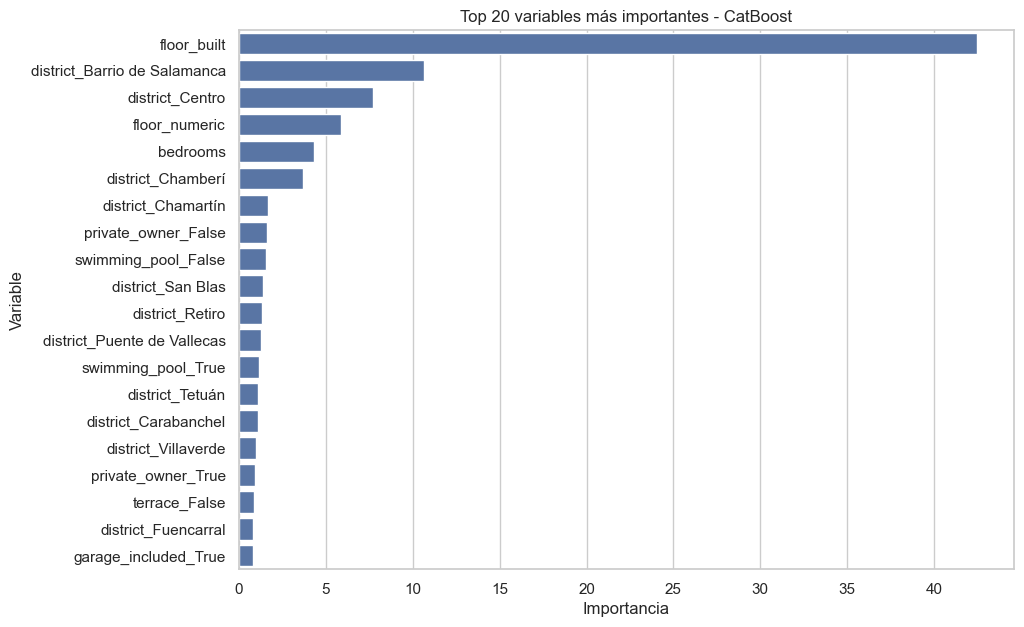

In [301]:
top_importance = importance_df.head(20)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_importance,
    x="Importancia",
    y="Variable"
)

plt.title("Top 20 variables más importantes - CatBoost")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

Agrupando variables categóricas dummy en la variable original

In [302]:
def agrupar_importancia_por_variable_original(importance_df, numeric_features, categorical_features):
    df_grouped = importance_df.copy()
    
    def obtener_variable_original(nombre):
        if nombre in numeric_features:
            return nombre
        
        for cat in categorical_features:
            if nombre.startswith(cat + "_"):
                return cat
        
        return nombre
    
    df_grouped["Variable_original"] = df_grouped["Variable"].apply(obtener_variable_original)
    
    agrupado = (
        df_grouped
        .groupby("Variable_original")["Importancia"]
        .sum()
        .sort_values(ascending=False)
        .reset_index()
    )
    
    return agrupado

In [303]:
importance_agrupada_df = agrupar_importancia_por_variable_original(
    importance_df,
    numeric_features,
    categorical_features
)

display(importance_agrupada_df)

,Variable_original,Importancia
0,floor_built,"42,48"
1,district,"36,48"
2,floor_numeric,"5,86"
3,bedrooms,"4,30"
4,swimming_pool,"2,70"
5,private_owner,"2,58"
6,terrace,"1,48"
7,garage_included,"1,47"
8,balcony,"1,01"
9,storeroom,"0,98"


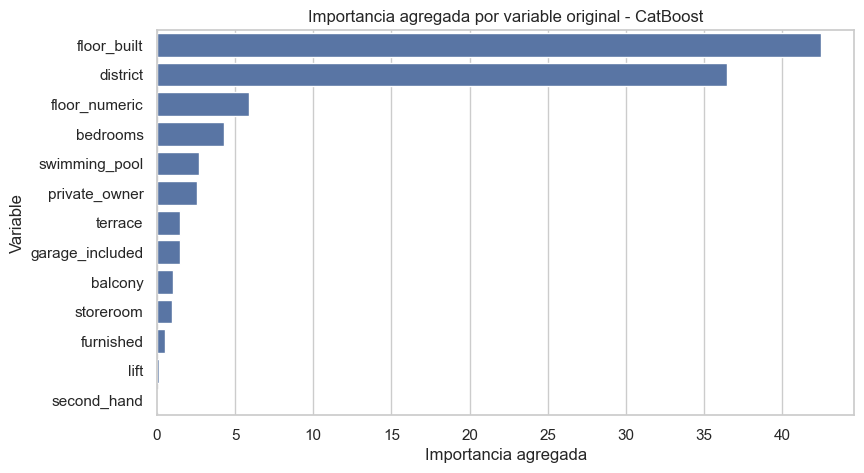

In [304]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=importance_agrupada_df,
    x="Importancia",
    y="Variable_original"
)

plt.title("Importancia agregada por variable original - CatBoost")
plt.xlabel("Importancia agregada")
plt.ylabel("Variable")
plt.show()

## SHAP

In [305]:
import shap

X_shap = X_test_transformed

print("Filas usadas para SHAP:", X_shap.shape[0])
print("Columnas usadas para SHAP:", X_shap.shape[1])

explainer = shap.Explainer(modelo_fitted, X_shap)
shap_values = explainer(X_shap)

Filas usadas para SHAP: 1485
Columnas usadas para SHAP: 42


 95%|=================== | 1412/1485 [00:14<00:00]       

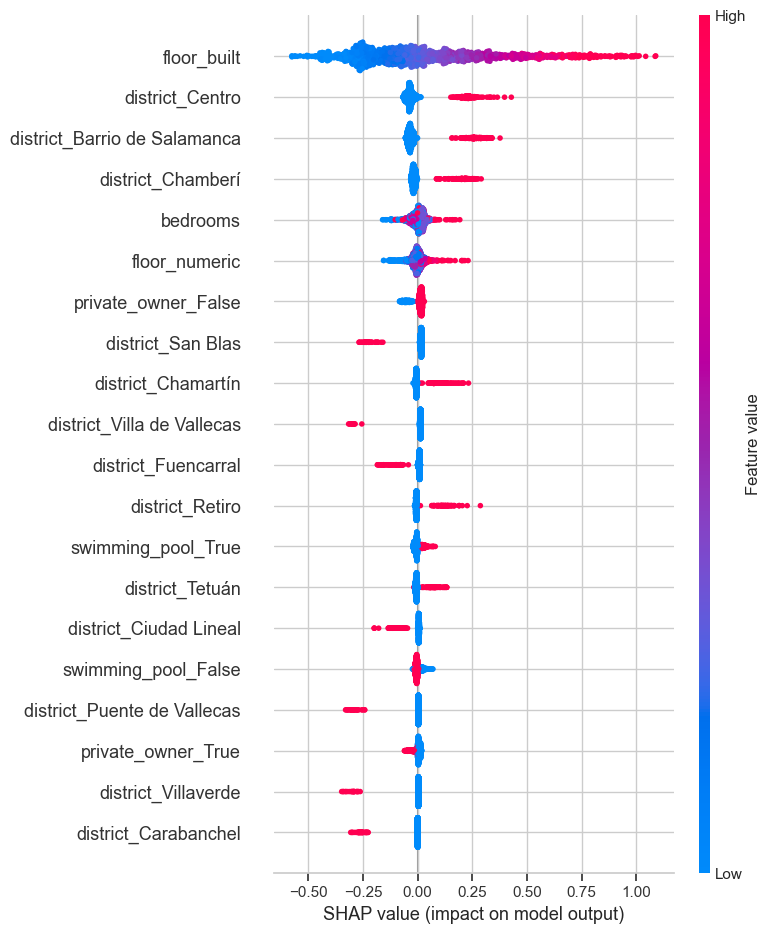

In [306]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names
)

In [309]:
def agrupar_shap_por_variable_original(shap_importance_df, numeric_features, categorical_features):
    df_grouped = shap_importance_df.copy()
    
    def obtener_variable_original(nombre):
        if nombre in numeric_features:
            return nombre
        
        for cat in categorical_features:
            if nombre.startswith(cat + "_"):
                return cat
        
        return nombre
    
    df_grouped["Variable_original"] = df_grouped["Variable"].apply(obtener_variable_original)
    
    agrupado = (
        df_grouped
        .groupby("Variable_original")["Importancia_SHAP_media"]
        .sum()
        .sort_values(ascending=False)
        .reset_index()
    )
    
    return agrupado

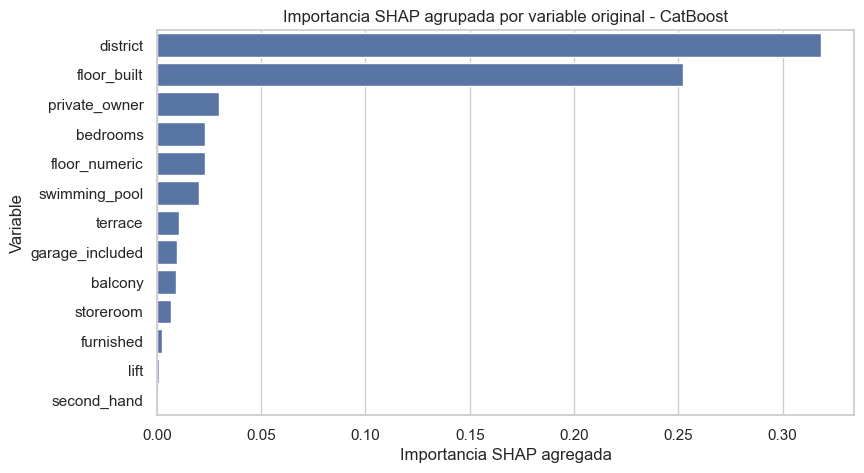

In [311]:
shap_importance = np.abs(shap_values.values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Variable": feature_names,
    "Importancia_SHAP_media": shap_importance
}).sort_values("Importancia_SHAP_media", ascending=False)

shap_importance_agrupada_df = agrupar_shap_por_variable_original(
    shap_importance_df,
    numeric_features,
    categorical_features
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=shap_importance_agrupada_df,
    x="Importancia_SHAP_media",
    y="Variable_original"
)

plt.title("Importancia SHAP agrupada por variable original - CatBoost")
plt.xlabel("Importancia SHAP agregada")
plt.ylabel("Variable")
plt.show()